# 04 – RNN Ablation Study for Automatic Modulation Classification

This notebook analyzes **pretrained RNN models** (GRU and LSTM variants)
for Automatic Modulation Classification (AMC) using the RadioML 2016.10A
dataset.

All RNN models were trained offline using the **code-only** script
`4_rnn_codeonly.py`, which runs two stages:

1. **Architecture ablation** (GRU vs LSTM, hidden size, depth, bidirectionality).
2. **Training-hyperparameter ablation** (optimizer, scheduler, warmup, AMP,
   label smoothing, mixup, weight decay, etc.) on the best architecture.

The approach here extends the 1D-CNN ablation by running the same two-stage
procedure for RNNs: first over architectures, then over training
hyperparameters.

**This notebook does NOT retrain any models.**

Instead, it:

- Loads:
  - Best RNN checkpoints (`rnn_A_amp_off_best.pth`)
  - Training histories (`histories.pkl`)
  - Ablation summary tables (`ablation_results.csv` / `.pkl`)
  - Summary plots (validation curves, loss curves, SNR curves)
- Rebuilds the `AMCRNN` architecture used in training.
- Evaluates accuracy, loss, and per-SNR performance on the
  RadioML 2016.10A test set.
- Summarizes which RNN configuration is selected as the **final baseline**
  and how it compares qualitatively with the 1D-CNN results.

---

## 0 Setup & Required Files





### 0.1 Dataset on Google Drive

- **Dataset**  
  - `RadioML2016_10A_dataset.pkl`  
  - Expected path in this notebook:  
    `/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl`

> If you store this file in a different place, update `data_path` in the first
> code cell accordingly.


In [1]:
# Mount Google Drive (or configure to where dataset is located)
from google.colab import drive
drive.mount('/content/drive')

# Path to dataset (adjust this path to where the data file is located)
data_path = '/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.2 GitHub repository and RNN artifacts

This notebook assumes the repository  
`Tutorial-Automatic-Modulation-Classification`  
has been cloned into:

`/content/Tutorial-Automatic-Modulation-Classification`

From that repo we use:

- `src/data.py` – `load_radioml_pkl_dataset` and helpers for the RadioML 2016.10A dataset.
- `src/data_utils.py` – utilities to convert the dictionary representation into
  `(N, 2, 128)` I/Q arrays.
- `data/rnn/` – precomputed RNN ablation results (tables, histories, and plots) copied
  from previous training runs with `4_rnn_codeonly.py`.



In [2]:
# --- Pull project from GitHub into Colab ---
import os, sys
REPO_URL = "https://github.com/Koosmaster/Tutorial-Automatic-Modulation-Classification.git"
REPO_DIR = "/content/Tutorial-Automatic-Modulation-Classification"
SRC_DIR  = f"{REPO_DIR}/src"

# Clone once
if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 "$REPO_URL" "$REPO_DIR"

# Add src/ to import path
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Loaded project from:", REPO_DIR)
print("src modules:", os.listdir(SRC_DIR))


Loaded project from: /content/Tutorial-Automatic-Modulation-Classification
src modules: ['train.py', 'plot_utils.py', 'models', 'eval_utils.py', 'Sources.md', 'data_utils.py', 'model_loading.py', 'data.py', 'exploration.py', 'models_1d.py']


### Data & model access

This notebook only **reads** precomputed artifacts; all RNN training was done
with `4_rnn_codeonly.py` using a A100 GPU on Google Colab. Stored in the GitHub:

- `data/rnn/rnn_arch_results/`  
  Stage-1 architecture ablation results  
  (`ablation_results.csv`, AUC-over-SNR bar plot, architecture learning curves,
   and accuracy-vs-SNR plot).

- `data/rnn/ablation_results.csv`  
  Stage-2 training-hyperparameter ablation summary.

- `data/rnn/best_model/`  
  Final RNN checkpoint and `manifest.json` describing the selected
  configuration.

All loss curves, accuracy tables, and SNR plots in this notebook are computed
from these saved artifacts.


In [17]:
from pathlib import Path

REPO_DIR = Path("/content/Tutorial-Automatic-Modulation-Classification")
RNN_RESULTS_DIR = REPO_DIR / "data" / "rnn"
PLOTS_DIR = RNN_RESULTS_DIR
ARCH_RESULTS_DIR = RNN_RESULTS_DIR / "rnn_arch_results"
BEST_MODEL_DIR = RNN_RESULTS_DIR / "best_model"
best_ckpt_path = BEST_MODEL_DIR / "rnn_A_amp_off_best.pth"
manifest_path  = BEST_MODEL_DIR / "manifest.json"


### 0.3 Imports and Configuration

Dependencies used in this notebook:

- **PyTorch**  
  For model definition, checkpoint loading, evaluation, and GPU acceleration.

- **NumPy**  
  For array operations, SNR-wise aggregation, and general numerical utilities.

- **Matplotlib / Seaborn**

  For producing training curves, SNR-dependent accuracy plots, and confusion matrices.

- **pandas**  
  For handling results tables, ablation summaries, and per-configuration metrics.

- **scikit-learn**  
  For metrics such as accuracy, classification report, and confusion matrices.


In [4]:
# Main Libraries
import sys, platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
import random
import pandas as pd
import importlib
from IPython.display import Image, display

# Plotting Utilities
from IPython.display import HTML

# Train/Val/Test Splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

If running in Google Colab, enable GPU acceleration for training deep models and mount Google Drive to access the dataset.

In [5]:
# Environment check & dependency install
print(f"Python: {sys.version.split()[0]}  |  Platform: {platform.platform()}")

# Uncomment to install from requirements.txt if running locally
# %pip install -q -r requirements.txt

Python: 3.12.12  |  Platform: Linux-6.6.105+-x86_64-with-glibc2.35


---

## 1 Experiment Overview



### 1.1 Summary of Main Results

| Aspect                          | Summary                                                                                                                                                                                                 |
|---------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Stage 1 – Architecture sweep    | The 2-layer GRU with larger hidden size, `GRU_big_h256_L2_do0.3`, clearly outperforms the other variants and becomes the backbone for Stage 2.                                                         |
| Stage 1 – Test accuracies       | - `GRU_base_h128_L1` → test acc ≈ **49.9%**  <br> <br> - `GRU_bidir_h128_L1` → test acc ≈ **43.6%** <br> <br> - `LSTM_base_h128_L1` → test acc ≈ **32.6%** <br> <br> - `GRU_big_h256_L2_do0.3` → test acc ≈ **55.4%** |
| Stage 2 – Best configuration    | In the training-hyperparameter sweep, the best setting (`A_amp_off` on the `GRU_big_h256_L2_do0.3` backbone) reaches ≈ **55.4%** test accuracy.                                                       |
| Stage 2 – Effect of knob changes| Other configurations (`CONTROL`, `A_ls_off`, `A_sched_cosine`, `A_decay_all_params`) are within ≈0.1–0.2 percentage points of the best; training tricks mainly change **dynamics & stability**, not peak accuracy. |


---

## 2 Dataset Loading and Dataloaders




**Goal.** Prepare the RadioML I/Q data for deep learning models (PyTorch tensors), document the label choices, and explain how the data is split and reshaped.

- **Labels.** Classification by **modulation type only**; SNR is stored separately and later used for per-SNR analysis.
- **Raw shapes.** Each sample is a complex baseband signal of shape `(2, 128)`, representing I and Q over 128 time points.
- **Splits.** Create train/validation/test splits stratified by modulation label with a fixed random seed for reproducibility.
- **Scaling / normalization.** I apply channel-wise normalization suitable for neural networks (keeping I/Q structure intact).
- **DL tensor format.**
  - For **RNNs**, inputs are shaped as `(batch_size, channels=2, length=128)`.


Dataset Summary
- **Source:** RadioML 2016.10A (DeepSig)  
- **Format:** Pickle file (`.pkl`) containing I/Q signal samples  
- **Classes:** 11 modulation types (8 digital, 3 analog)  
- **SNR Range:** –20 dB to +18 dB (2 dB steps)  
- **Samples:** Each record has 128 complex I/Q samples  

---
SOURCE: https://www.kaggle.com/code/ahmedali30/knndtamc-amc-rml2016a-updated

### 2.1 Load Preprocessed RadioML Dataset

Load:
- `X_val`, `y_val`  
- `X_test`, `y_test`  
- `snr_test` values (for SNR-dependent accuracy)

The input shape for all models is:

- **`(num_samples, 2, 128)`**, where:
  - `2` corresponds to the I and Q channels, and  
  - `128` is the number of time samples per example.

For RNNs, this is later viewed as sequences of length 128 with a 2-dimensional
feature vector at each time step (after permuting to `(batch, seq_len=128, features=2)`).


In [6]:
# Importing functions from Github in the src file
from data import load_radioml_pkl_dataset, radioml_splits
from data_utils import dict_to_iq_arrays

In [7]:
radioml_data, mod_classes, snr_values = load_radioml_pkl_dataset(data_path)
X, y, snr_list = dict_to_iq_arrays(radioml_data)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr_list shape:", snr_list.shape)


Loading RadioML 2016.10A dataset from: /content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl
Found 11 raw modulation types.
Loaded dataset contains 11 modulation classes and 20 SNR values.
Dataset summary: 11 mods, 20 SNRs, 220,000 total samples.
X shape: (220000, 2, 128)
y shape: (220000,)
snr_list shape: (220000,)


### 2.2 Dataloader Construction

PyTorch `DataLoader` for:
- validation set  
- test set  
- SNR-labeled test set  

Batch size = **256**  

In [8]:
# Encode modulation labels to integers 0..C-1
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train / val / test splits (e.g., 70 / 15 / 15)
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y_enc, snr_list, test_size=0.3, stratify=y_enc, random_state=42
)

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Convert labels to tensors
y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()




---

## 3 RNN Architecture


### 3.1 AMC RNN backbone

All configurations share the same RNN backbone, implemented as `AMCRNN` in the
training script:

- **Input:** complex baseband as two real-valued channels,
  shaped `(B, 2, 128)`.
- **Reshaping:** permute to `(B, 128, 2)` so that:
  - time is the sequence dimension (length 128), and
  - the feature dimension is 2 (I & Q).
- **Recurrent layers:** a stack of GRU or LSTM layers with configurable
  - `cell` type (`"gru"` or `"lstm"`),
  - `hidden_size`,
  - `num_layers`,
  - `bidirectional` flag,
  - dropout applied between recurrent layers when `num_layers > 1`.
- **Readout:** Logits of shape `(B, num_classes)`.
- **Initialization:** linear layers use Kaiming-normal initialization with
  zero biases.




### 3.2 Architecture configurations

The architecture sweep in Stage 1 explores four variants, encoded in
`RNN_ARCH_CONFIGS`:

| Name                     | Cell | Hidden size | # Layers | Bidirectional | Dropout |
|--------------------------|------|-------------|----------|--------------|---------|
| `GRU_base_h128_L1`       | GRU  | 128         | 1        | No           | 0.0     |
| `GRU_big_h256_L2_do0.3`  | GRU  | 256         | 2        | No           | 0.3     |
| `GRU_bidir_h128_L1`      | GRU  | 128         | 1        | Yes          | 0.0     |
| `LSTM_base_h128_L1`      | LSTM | 128         | 1        | No           | 0.0     |

Stage 1 runs the same training setup on each of these variants and chooses the
one with the highest validation accuracy as the **best RNN architecture** for
the hyperparameter ablations in Stage 2.

In this run, `GRU_big_h256_L2_do0.3` achieves the highest validation and test
accuracy (≈55.4% test acc); therefore, all Stage 2 hyperparameter ablations use this
backbone.

### **Model Architecture (RNN)**

| Component      | Setting                                                                                           |
|---------------|---------------------------------------------------------------------------------------------------|
| Input shape    | `(2 channels, 128 samples)` raw I/Q, reshaped to a sequence `(T = 128, F = 2)`                   |
| Recurrent core| 2-layer **GRU** (`cell = "gru"`)                                                                  |
| Hidden size   | 256 units per layer                                                                              |
| Direction     | **Unidirectional** (no bidirectional branches)                                                   |
| Dropout       | `dropout = 0.3` applied between GRU layers                                                       |
| Readout       | Final hidden state of the top GRU layer → fully connected layer → logits for 11 modulation classes |
| Classifier    | Linear head mapping from hidden size 256 → 11 classes                                            |
| Weight init   | PyTorch defaults for GRU; Linear layers use standard Kaiming/Xavier-style initialization         |
| Parameters    | On the order of a few hundred thousand trainable parameters (compact compared to many CNNs)      |

---

### **Optimization (best RNN config: `A_amp_off` on `GRU_big_h256_L2_do0.3`)**

| Parameter             | Setting                                                                                                        |
|-----------------------|----------------------------------------------------------------------------------------------------------------|
| Optimizer             | **Adam**                                                                                                       |
| Learning rate         | Default Adam learning rate used in the training script (typical value ≈ `1e-3`)                                |
| Weight decay          | Applied to main weight tensors (e.g., Linear / recurrent weight matrices); biases and norm parameters excluded |
| Gradient clipping     | Enabled if specified in the training script (to stabilize RNN training on long sequences)                      |
| AMP                   | **Disabled** (full-precision training); this distinguishes `A_amp_off` from the CONTROL configuration         |

---

### **Scheduler**

| Parameter  | Setting                                                                                              |
|-----------|------------------------------------------------------------------------------------------------------|
| Type      | **StepLR**                                                                                           |
| Step size | Approximately one third of the total number of epochs (e.g., `step_size ≈ epochs / 3`)              |
| Gamma     | `0.1` (learning rate is multiplied by 0.1 at each step)                                              |
| Warmup    | **Disabled** in the best configuration; a warmup ablation was tested but did not improve performance |

---

### **Regularization**

| Parameter        | Setting                                                                                                        |
|-----------------|----------------------------------------------------------------------------------------------------------------|
| Label smoothing | Enabled in the best RNN baseline (e.g., smoothing ≈ `0.1`) to soften hard targets                              |
| Mixup           | **Disabled** in the best configuration; mixup variants were tested but did not yield higher peak accuracy      |
| Dropout         | `0.3` between GRU layers (no additional dropout in the classifier head)                                        |
| Sequence length | Fixed-length windows of 128 complex samples, which implicitly regularizes by limiting temporal context          |

---

### **Training Configuration**

| Parameter   | Setting                                                                                         |
|------------|--------------------------------------------------------------------------------------------------|
| Precision  | Full **FP32** (AMP off)                                                                         |
| Batch size | `256`                                                                                            |
| Epochs     | RNN ablation runs trained for **dozens of epochs** (roughly 50–80), with best-epoch checkpointing by validation accuracy |
| Shuffle    | `True` (per-epoch shuffling in the training DataLoader)                                          |
| Split      | 70% train, 15% validation, 15% test, stratified by modulation label                             |

---

### **Performance (RNN Ablation Study)**

| Metric                              | Value / Summary                                                                                     |
|-------------------------------------|-----------------------------------------------------------------------------------------------------|
| Test accuracy (best config)         | ≈ **0.554** (55.4%) on the RadioML 2016.10A test set                                               |
| Best configuration                  | **`A_amp_off`** on the **`GRU_big_h256_L2_do0.3`** backbone                                        |
| Competing configs                   | `CONTROL`, `A_ls_off`, `A_sched_cosine`, `A_decay_all_params` are within ≈0.1–0.2 percentage points |
|


## 4 Training Configurations & Ablations

All RNN experiments share the same basic training setup:

- Loss: cross-entropy with optional label smoothing.
- Batch size: **256**.
- Normalization: `NORM = "none"` (raw I/Q as `(2, 128)`), matching the other
  deep-learning experiments.
- Split: 70% train, 15% validation, 15% test, stratified by modulation label.
- Evaluation: overall test accuracy and accuracy vs SNR.

### 4.1 CONTROL configuration

The **CONTROL** setting is the default training configuration:

- Optimizer: **Adam**.
- Scheduler: **StepLR** with step size ≈ `num_epochs / 3` and decay factor `0.1`.
- Label smoothing: **0.1**.
- Mixup: **off**.
- Warmup: **off**.
- Weight decay: applied only to the main weight matrices (e.g., recurrent and linear weights); batch-norm / normalization parameters and biases are excluded.
- AMP: **on** (mixed precision) when running on GPU.

This configuration appears as `CONTROL` in `ablation_results.csv` and serves as
the **reference baseline**. The highest validation/test accuracy is achieved by `A_amp_off`, which is a
minor variant of CONTROL that simply disables AMP; their accuracies are within
≈0.2 percentage points of each other.



### 4.2 Hyperparameter ablations


| Name                  | Change relative to CONTROL                                      |
|-----------------------|-----------------------------------------------------------------|
| `CONTROL`             | Baseline as described above                                    |
| `A_mixup_on`          | Enables mixup data augmentation                                |
| `A_ls_off`            | Disables label smoothing (`label_smoothing = 0.0`)             |
| `A_sched_cosine`      | Replaces StepLR with cosine annealing                          |
| `A_warmup_on`         | Adds a short linear LR warmup at the start of training         |
| `A_decay_all_params`  | Applies weight decay to **all** parameters, including BN/bias  |
| `A_opt_sgd`           | Switches optimizer from Adam to SGD with momentum              |
| `A_amp_off`           | Disables AMP, forcing full-precision training                  |

Each configuration is trained for 50–80 epochs (depending on the stage) with
batch size 256, and recorded validation accuracy, test accuracy, training
time, and accuracy vs SNR.

### 4.3 Two-stage ablation procedure

The RNN study uses a two-stage structure:

1. **Stage 1 – architecture sweep**  
   Run `ARCH_ABLATIONS` on the RadioML dataset using the CONTROL training
   setup. The architecture with the highest validation accuracy is selected as
   the best RNN backbone (here: `GRU_big_h256_L2_do0.3`).

2. **Stage 2 – training-knob sweep**  
   Fix the winning architecture from Stage 1 and run the hyperparameter
   ablations listed above. In the artifacts used here, the configuration with
   the best validation and test accuracy is `A_amp_off`
   (CONTROL with AMP disabled). We treat `A_amp_off` as the **final RNN
   baseline**, while `CONTROL` remains the “no extra tricks” reference setting.




---



## 5 Precomputed ablation artifacts

All RNN results used in this notebook are stored under the repository path

`data/rnn/`

This directory contains:

- `ablation_results.csv` / `ablation_results.pkl` – per-configuration metrics
  exported from the code-only script.
- `histories.pkl` – a pickled dictionary of training and validation curves for
  all configurations.
- `BEST_acc.png`, `BEST_loss.png` – learning curves for the single best
  configuration.
- `val_accuracy_all_configs.png`, `loss_curves_all_configs.png` – comparison
  plots across all ablation runs.
- `snr_accuracy_comparison.png` – accuracy vs SNR for each configuration.
- `best_model/` – checkpoint and manifest for the final RNN baseline
  (in this run, `rnn_A_amp_off_best.pth` plus `manifest.json`).

The code cells that follow load these artifacts directly; no training happens
inside this notebook.


## 6 Stage 1 – Architecture ablation (GRU vs LSTM variants)

### 6.1 Table: per-architecture metrics

In [19]:
# Ablation table
ablation_df = pd.read_csv(ARCH_RESULTS_DIR / "ablation_results.csv")
display(ablation_df)

,Experiment,Val Best Acc (%),Test Acc (%),Train Time (s)
0,GRU_base_h128_L1,49.863636,49.942424,396.523828
1,GRU_big_h256_L2_do0.3,55.121212,55.448485,921.283123
2,GRU_bidir_h128_L1,43.366667,43.639394,449.630096
3,LSTM_base_h128_L1,32.672727,32.621212,403.427691


### 6.2 AUC-over-SNR by architecture

This bar chart summarizes the **mean accuracy over SNR** (“AUC-over-SNR”)
for each architecture, giving a single robustness score per model.

![AUC-over-SNR by Configuration](data/rnn/auc_over_snr_bar.png)


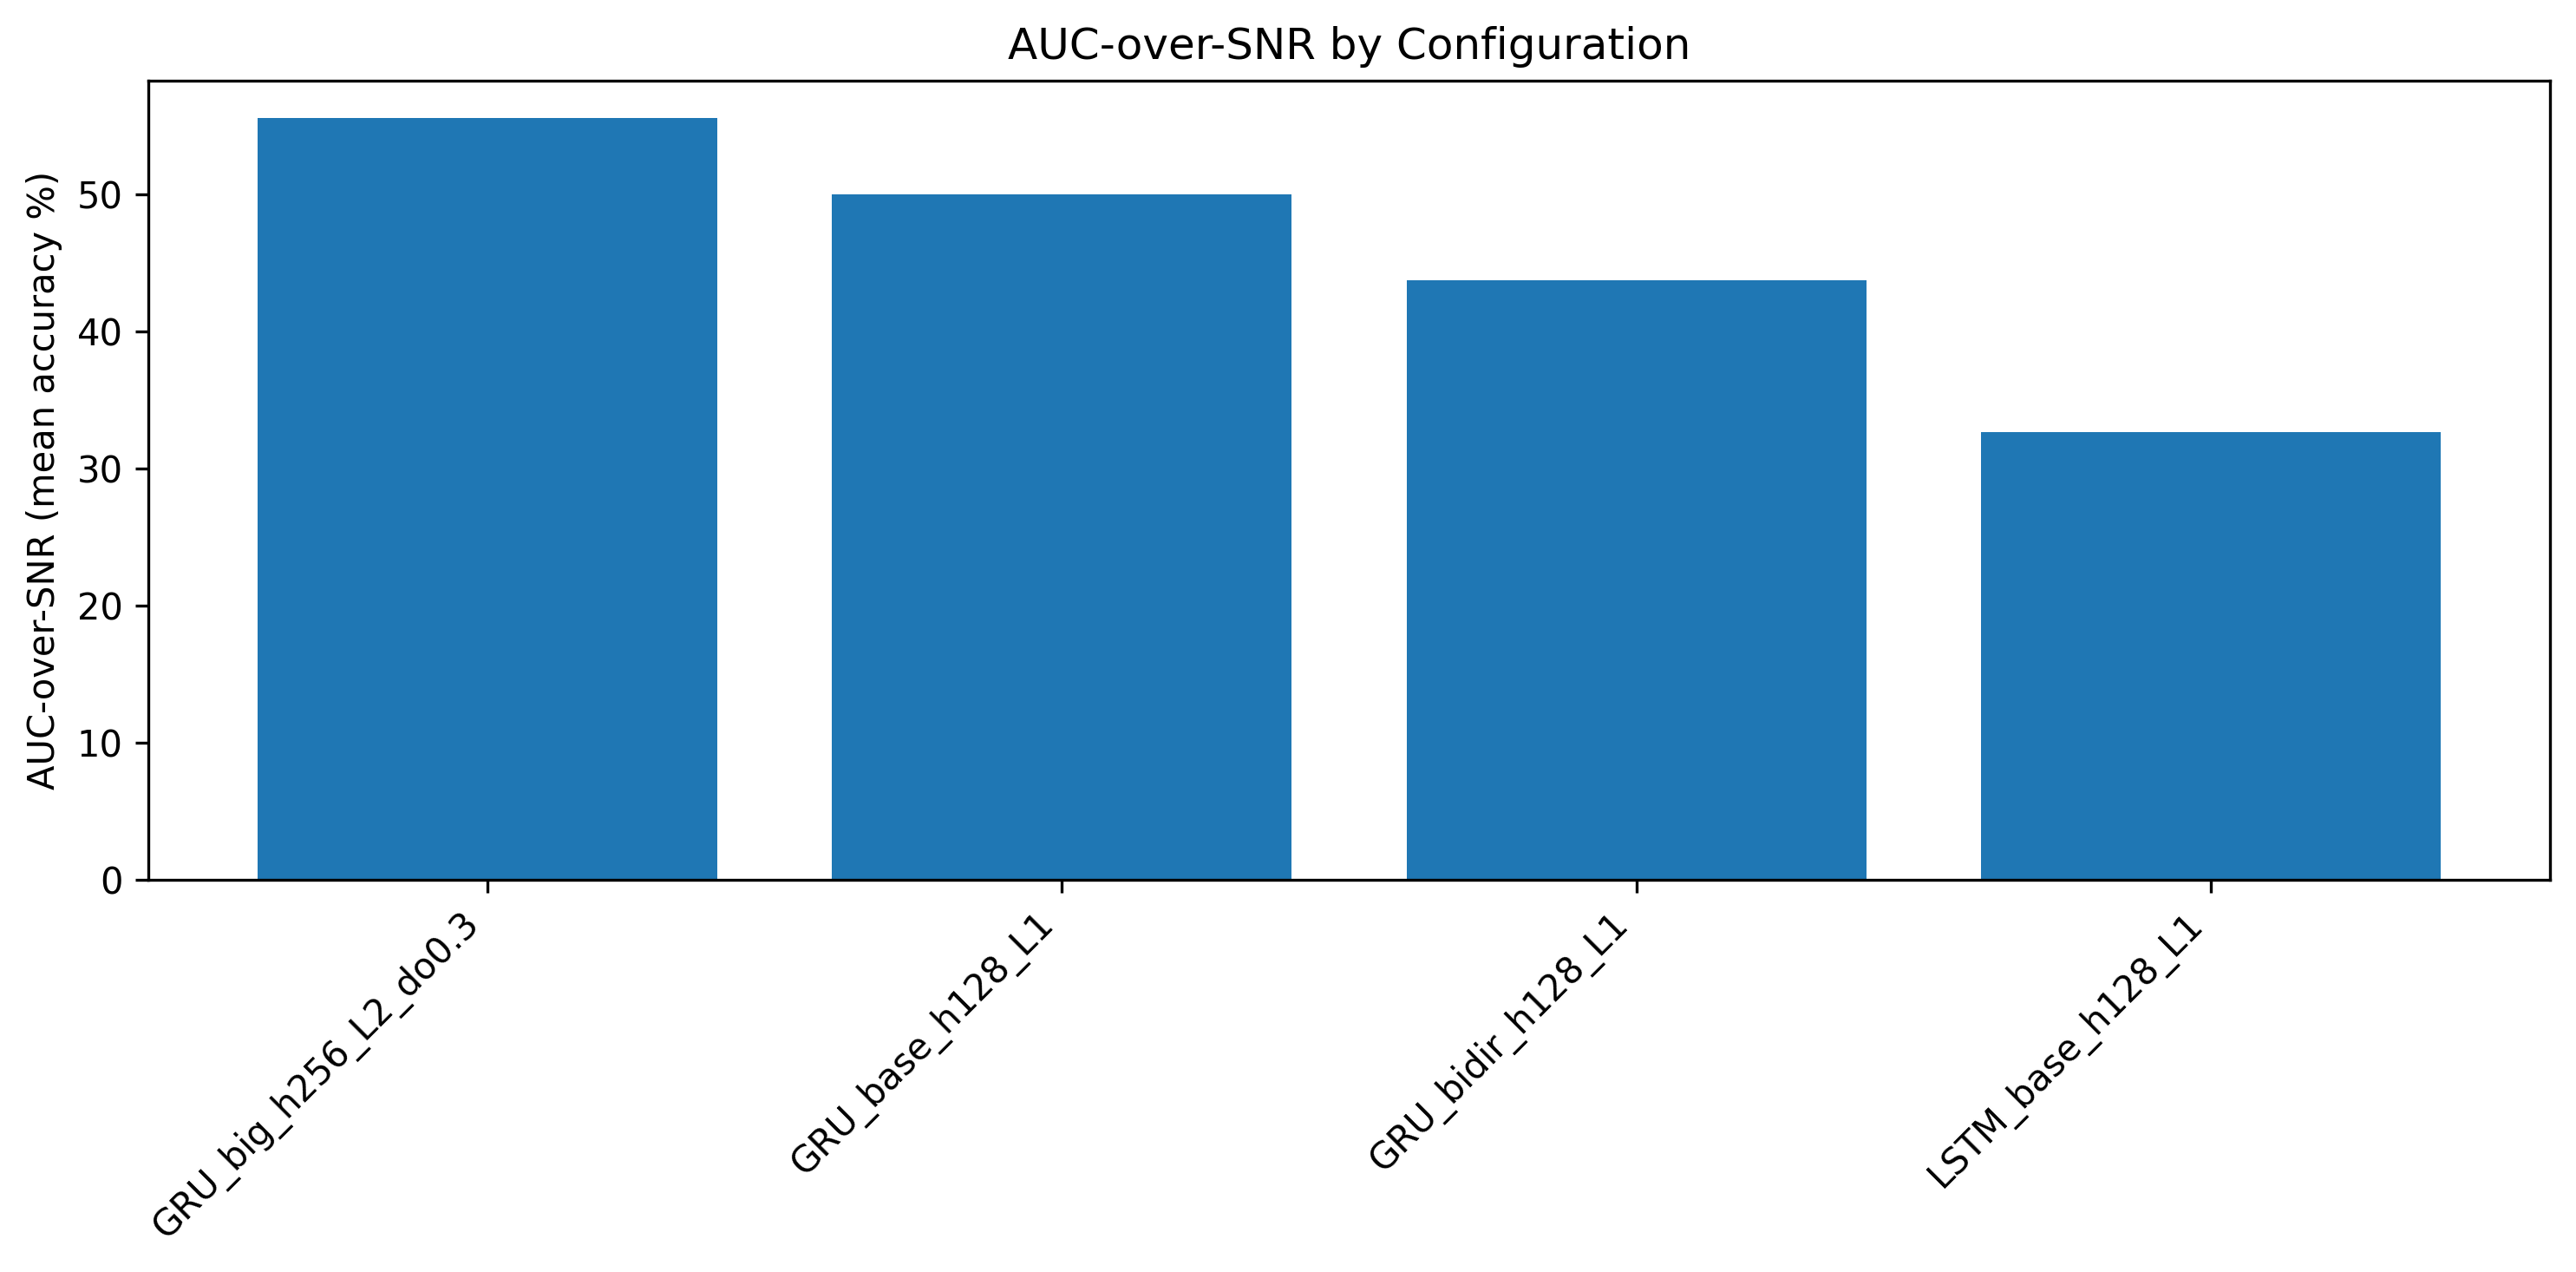

In [23]:
display(Image(filename=str(ARCH_RESULTS_DIR / "auc_over_snr_bar.png")))

### 6.3 Validation accuracy vs epoch (all architectures)

Validation accuracy curves for each RNN architecture over the training run.

![Validation Accuracy vs Epoch](data/rnn/val_accuracy_all_configs.png)


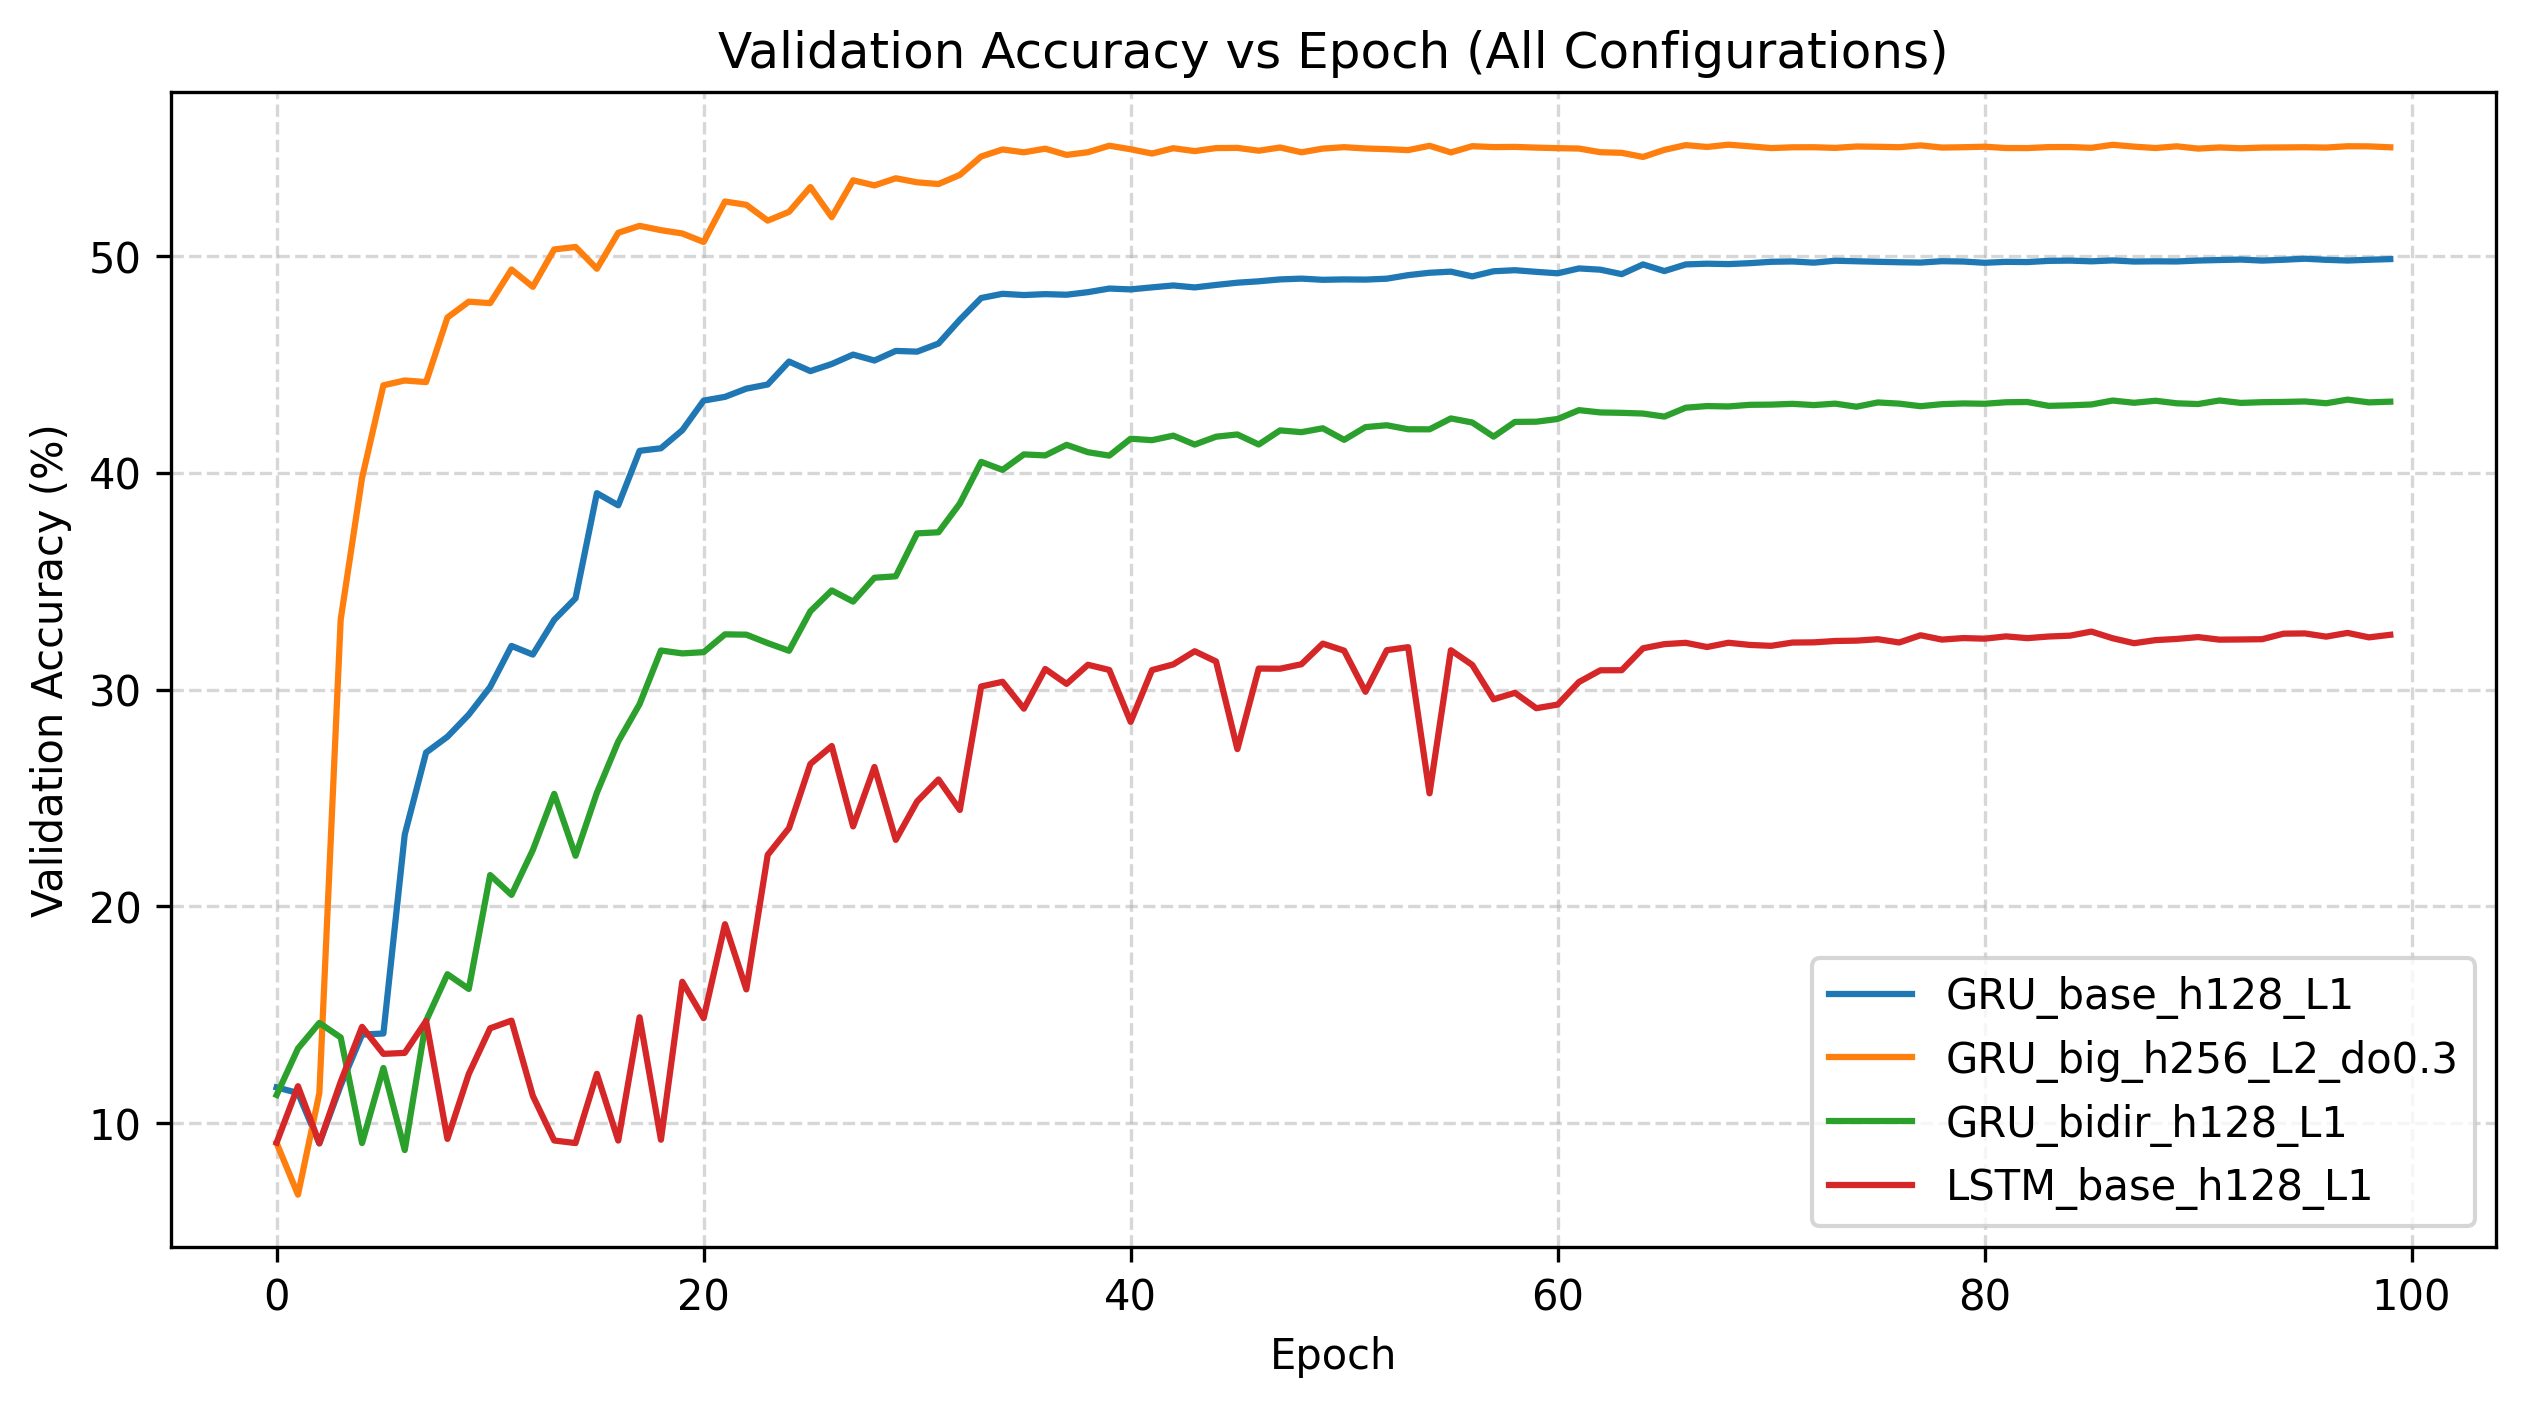

In [20]:
display(Image(filename=str(ARCH_RESULTS_DIR / "val_accuracy_all_configs.png")))

### 6.4 Training and validation loss vs epoch

Training and validation loss for each architecture, showing convergence speed
and overfitting tendencies.

![Training & Validation Loss vs Epoch](data/rnn/loss_curves_all_configs.png)


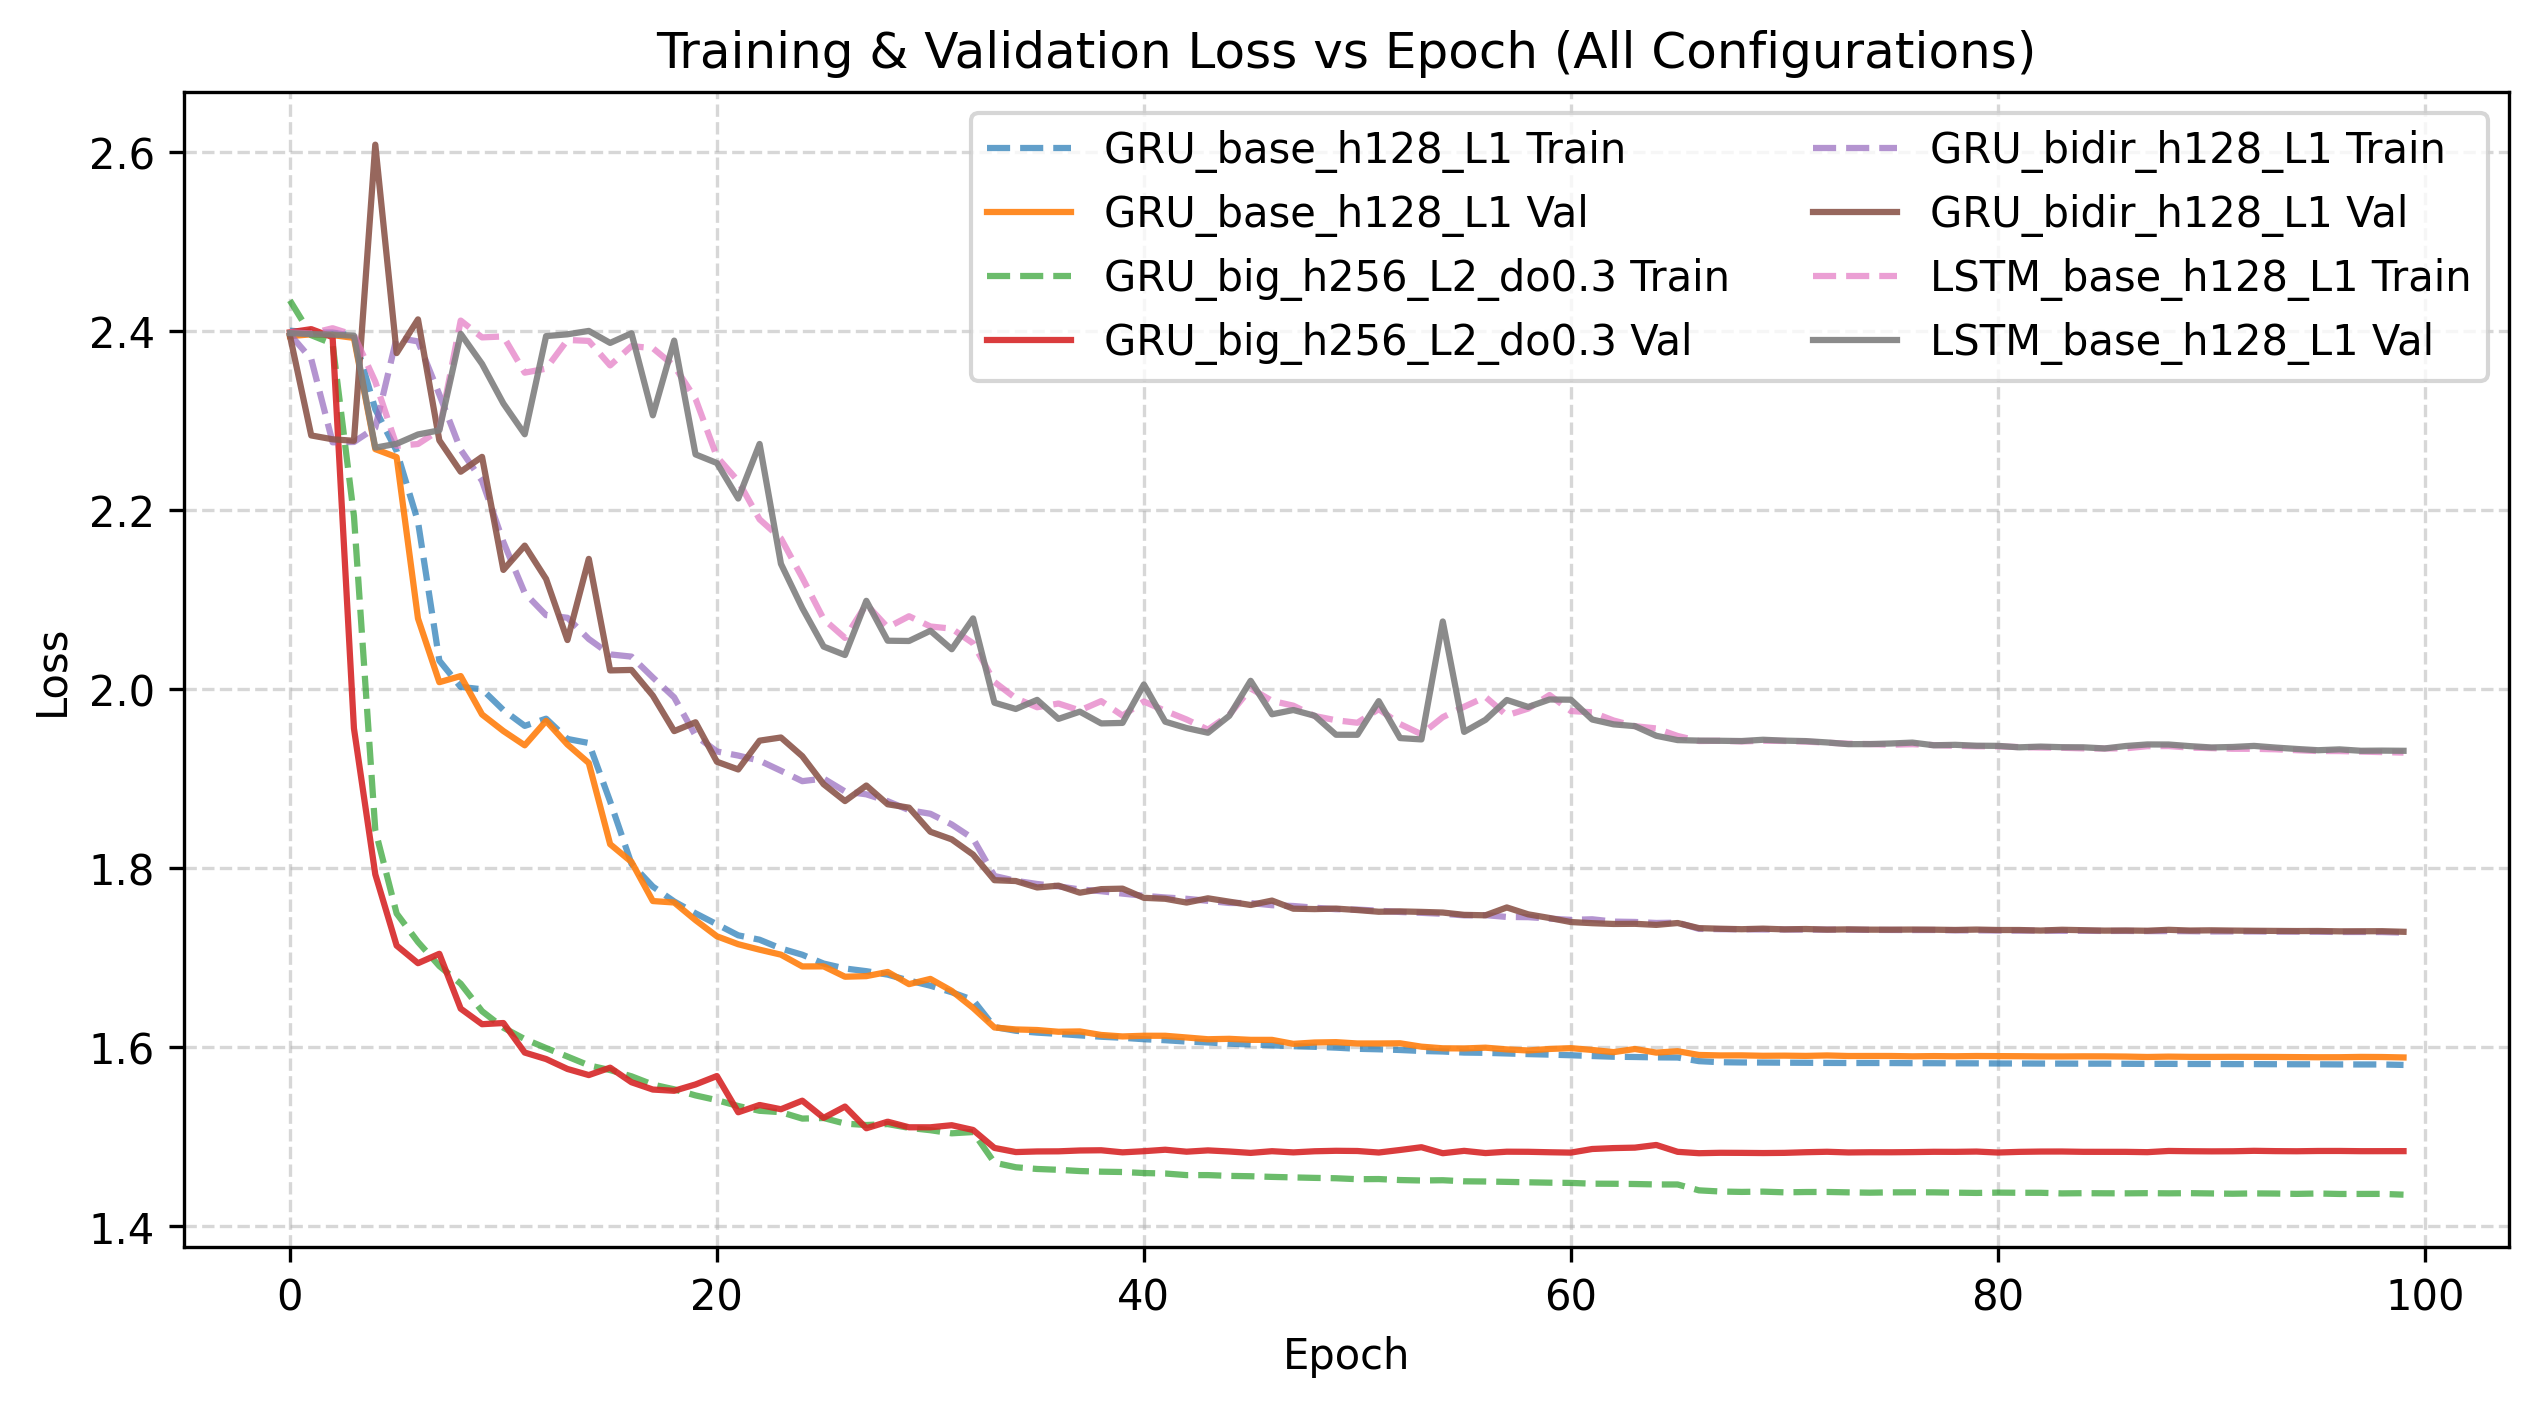

In [21]:
display(Image(filename=str(ARCH_RESULTS_DIR / "loss_curves_all_configs.png")))

### 6.5 Accuracy vs SNR (architecture comparison)

Test accuracy as a function of SNR for each architecture.

![Ablation Study: Accuracy vs SNR](data/rnn/snr_accuracy_comparison.png)


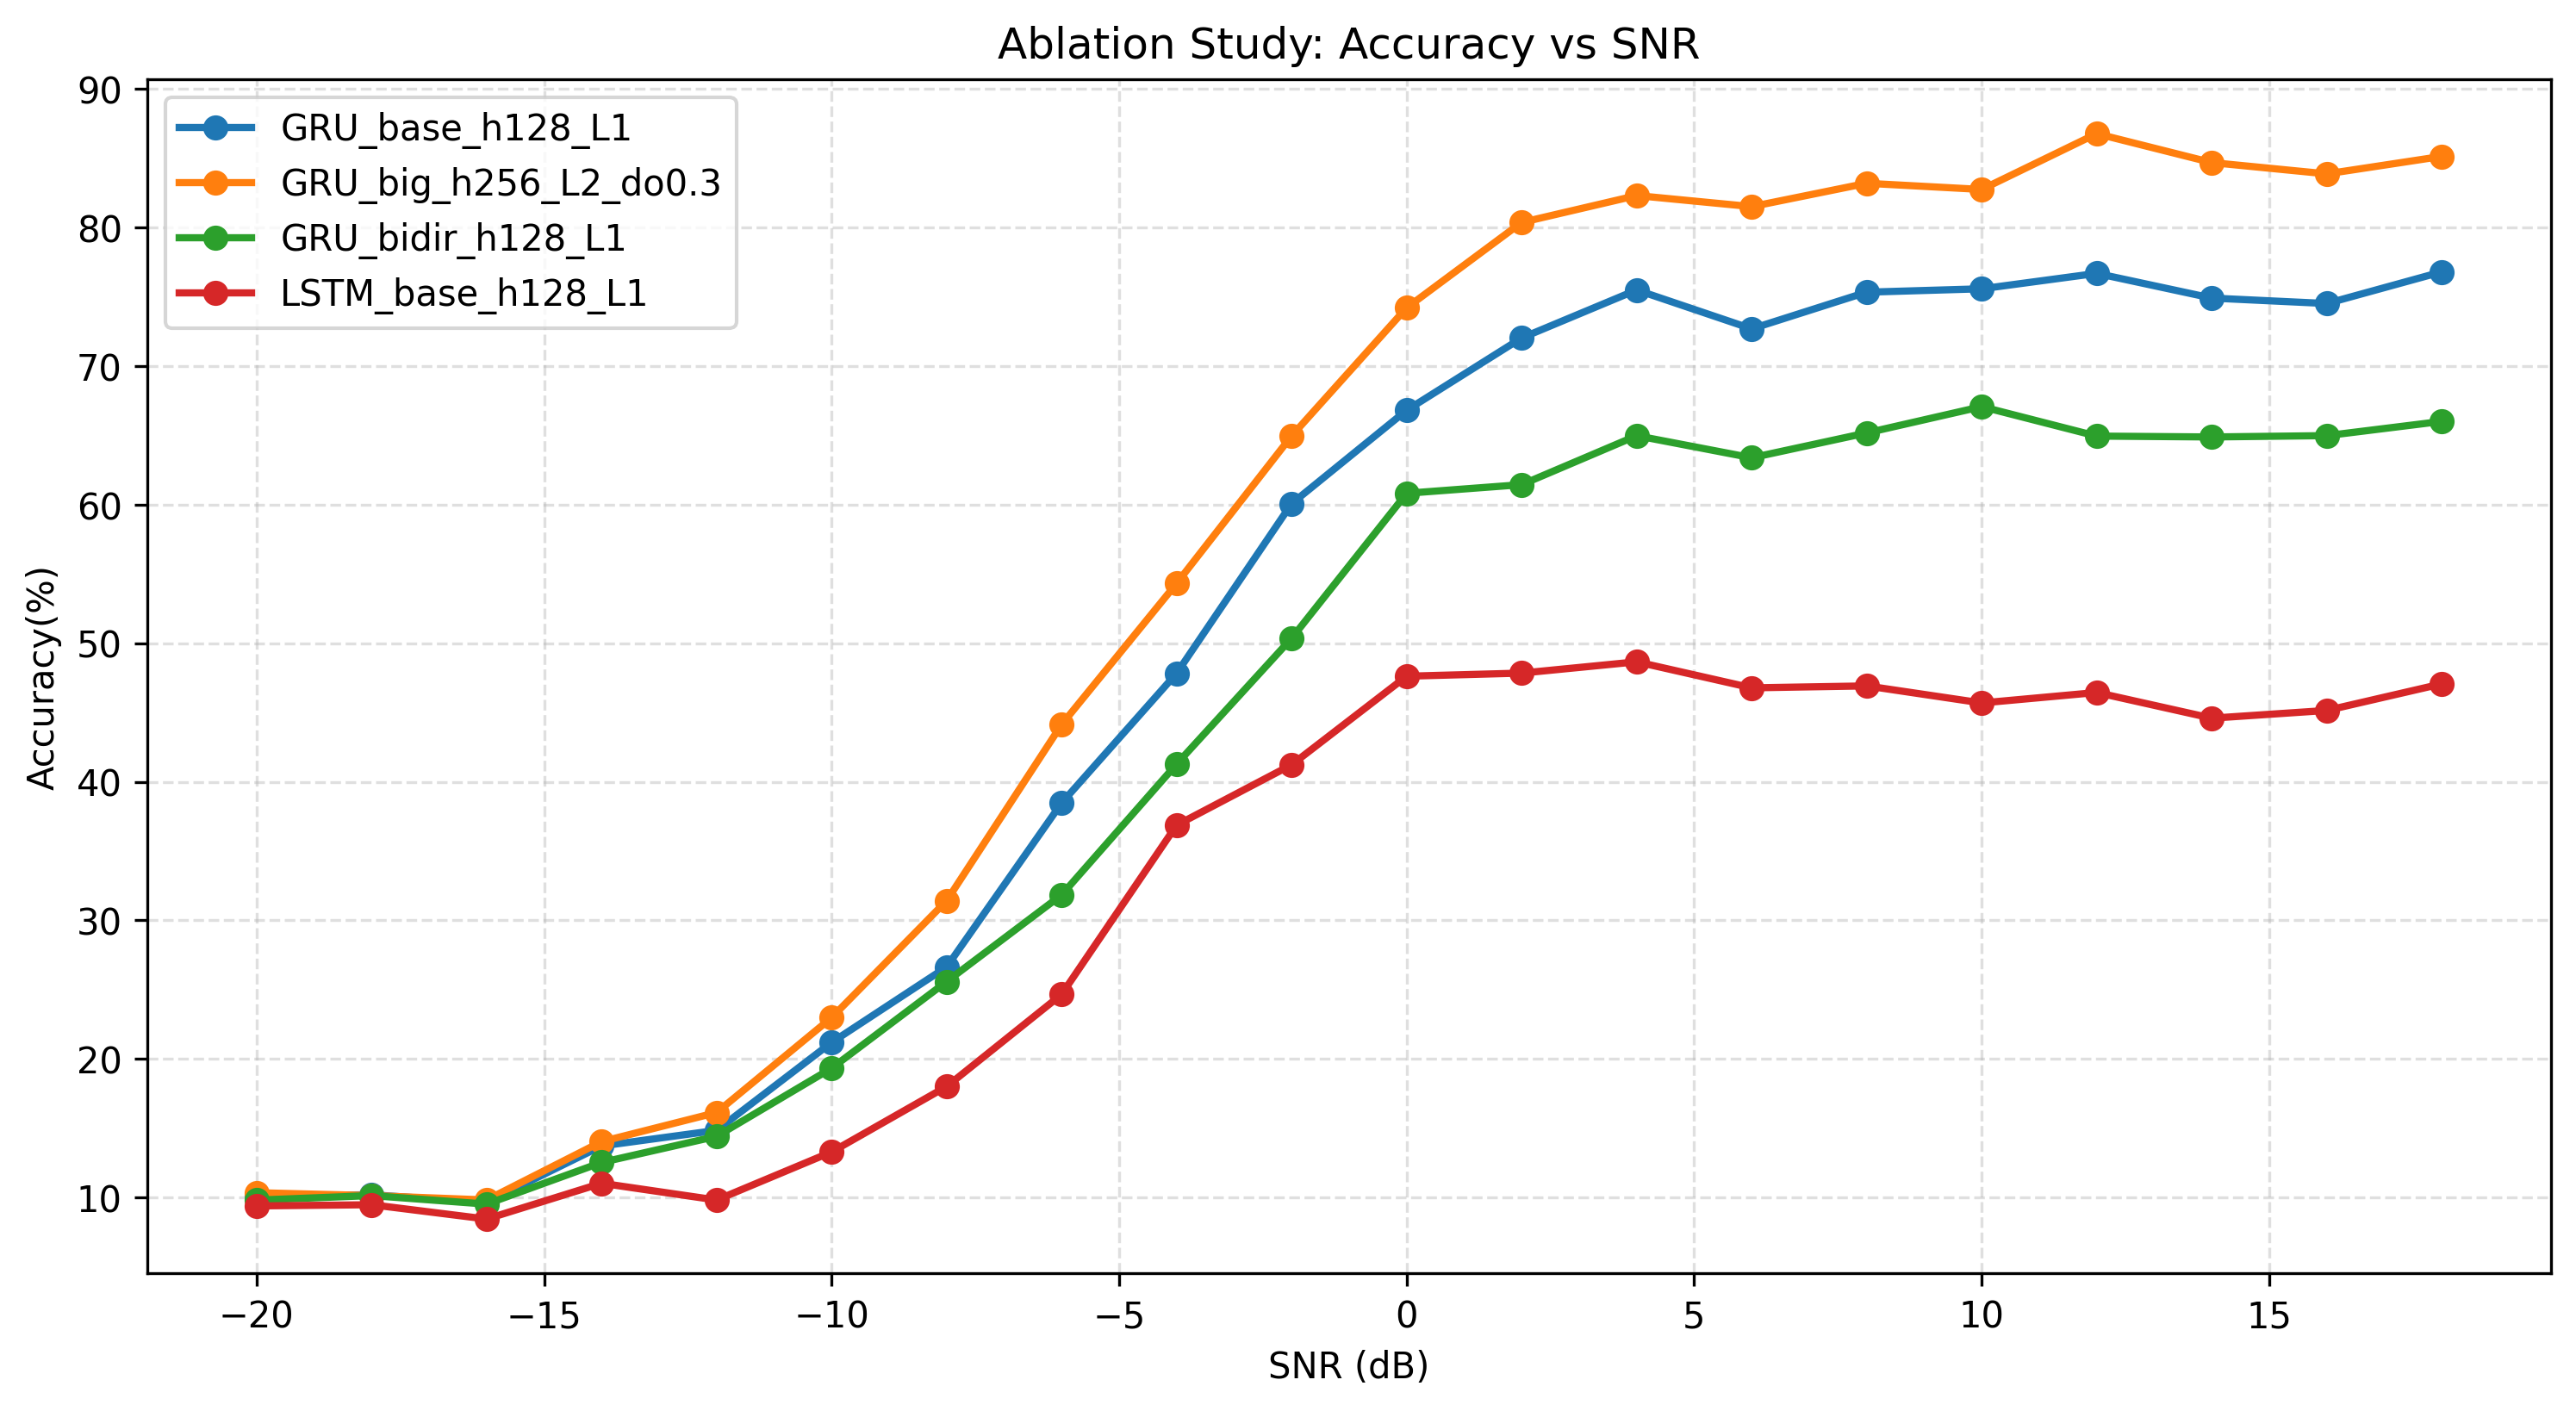

In [22]:
display(Image(filename=str(ARCH_RESULTS_DIR / "snr_accuracy_comparison.png")))

## 7 Stage 2 – Training-hyperparameter ablations

### 7.1 Ablation summary table

This table is the main summary of the RNN hyperparameter ablation study.


In [9]:
# Ablation table
ablation_df = pd.read_csv(RNN_RESULTS_DIR / "ablation_results.csv")
display(ablation_df)

,Experiment,Val Best Acc (%),Test Acc (%),Train Time (s)
0,CONTROL,54.863636,55.242424,750.856417
1,A_mixup_on,53.857576,54.124242,787.042937
2,A_ls_off,54.918182,55.336364,736.543987
3,A_sched_cosine,55.015152,55.348485,757.304189
4,A_warmup_on,54.963636,55.084848,751.201491
5,A_decay_all_params,54.863636,55.339394,740.543543
6,A_opt_sgd,12.936364,13.121212,734.723068
7,A_amp_off,55.121212,55.427273,664.691258


### 7.2 Validation accuracy vs epoch

`val_accuracy_all_configs.png` overlays the validation-accuracy curves for all
RNN configurations. It shows how quickly each setting converges and which ones
plateau at higher accuracy.

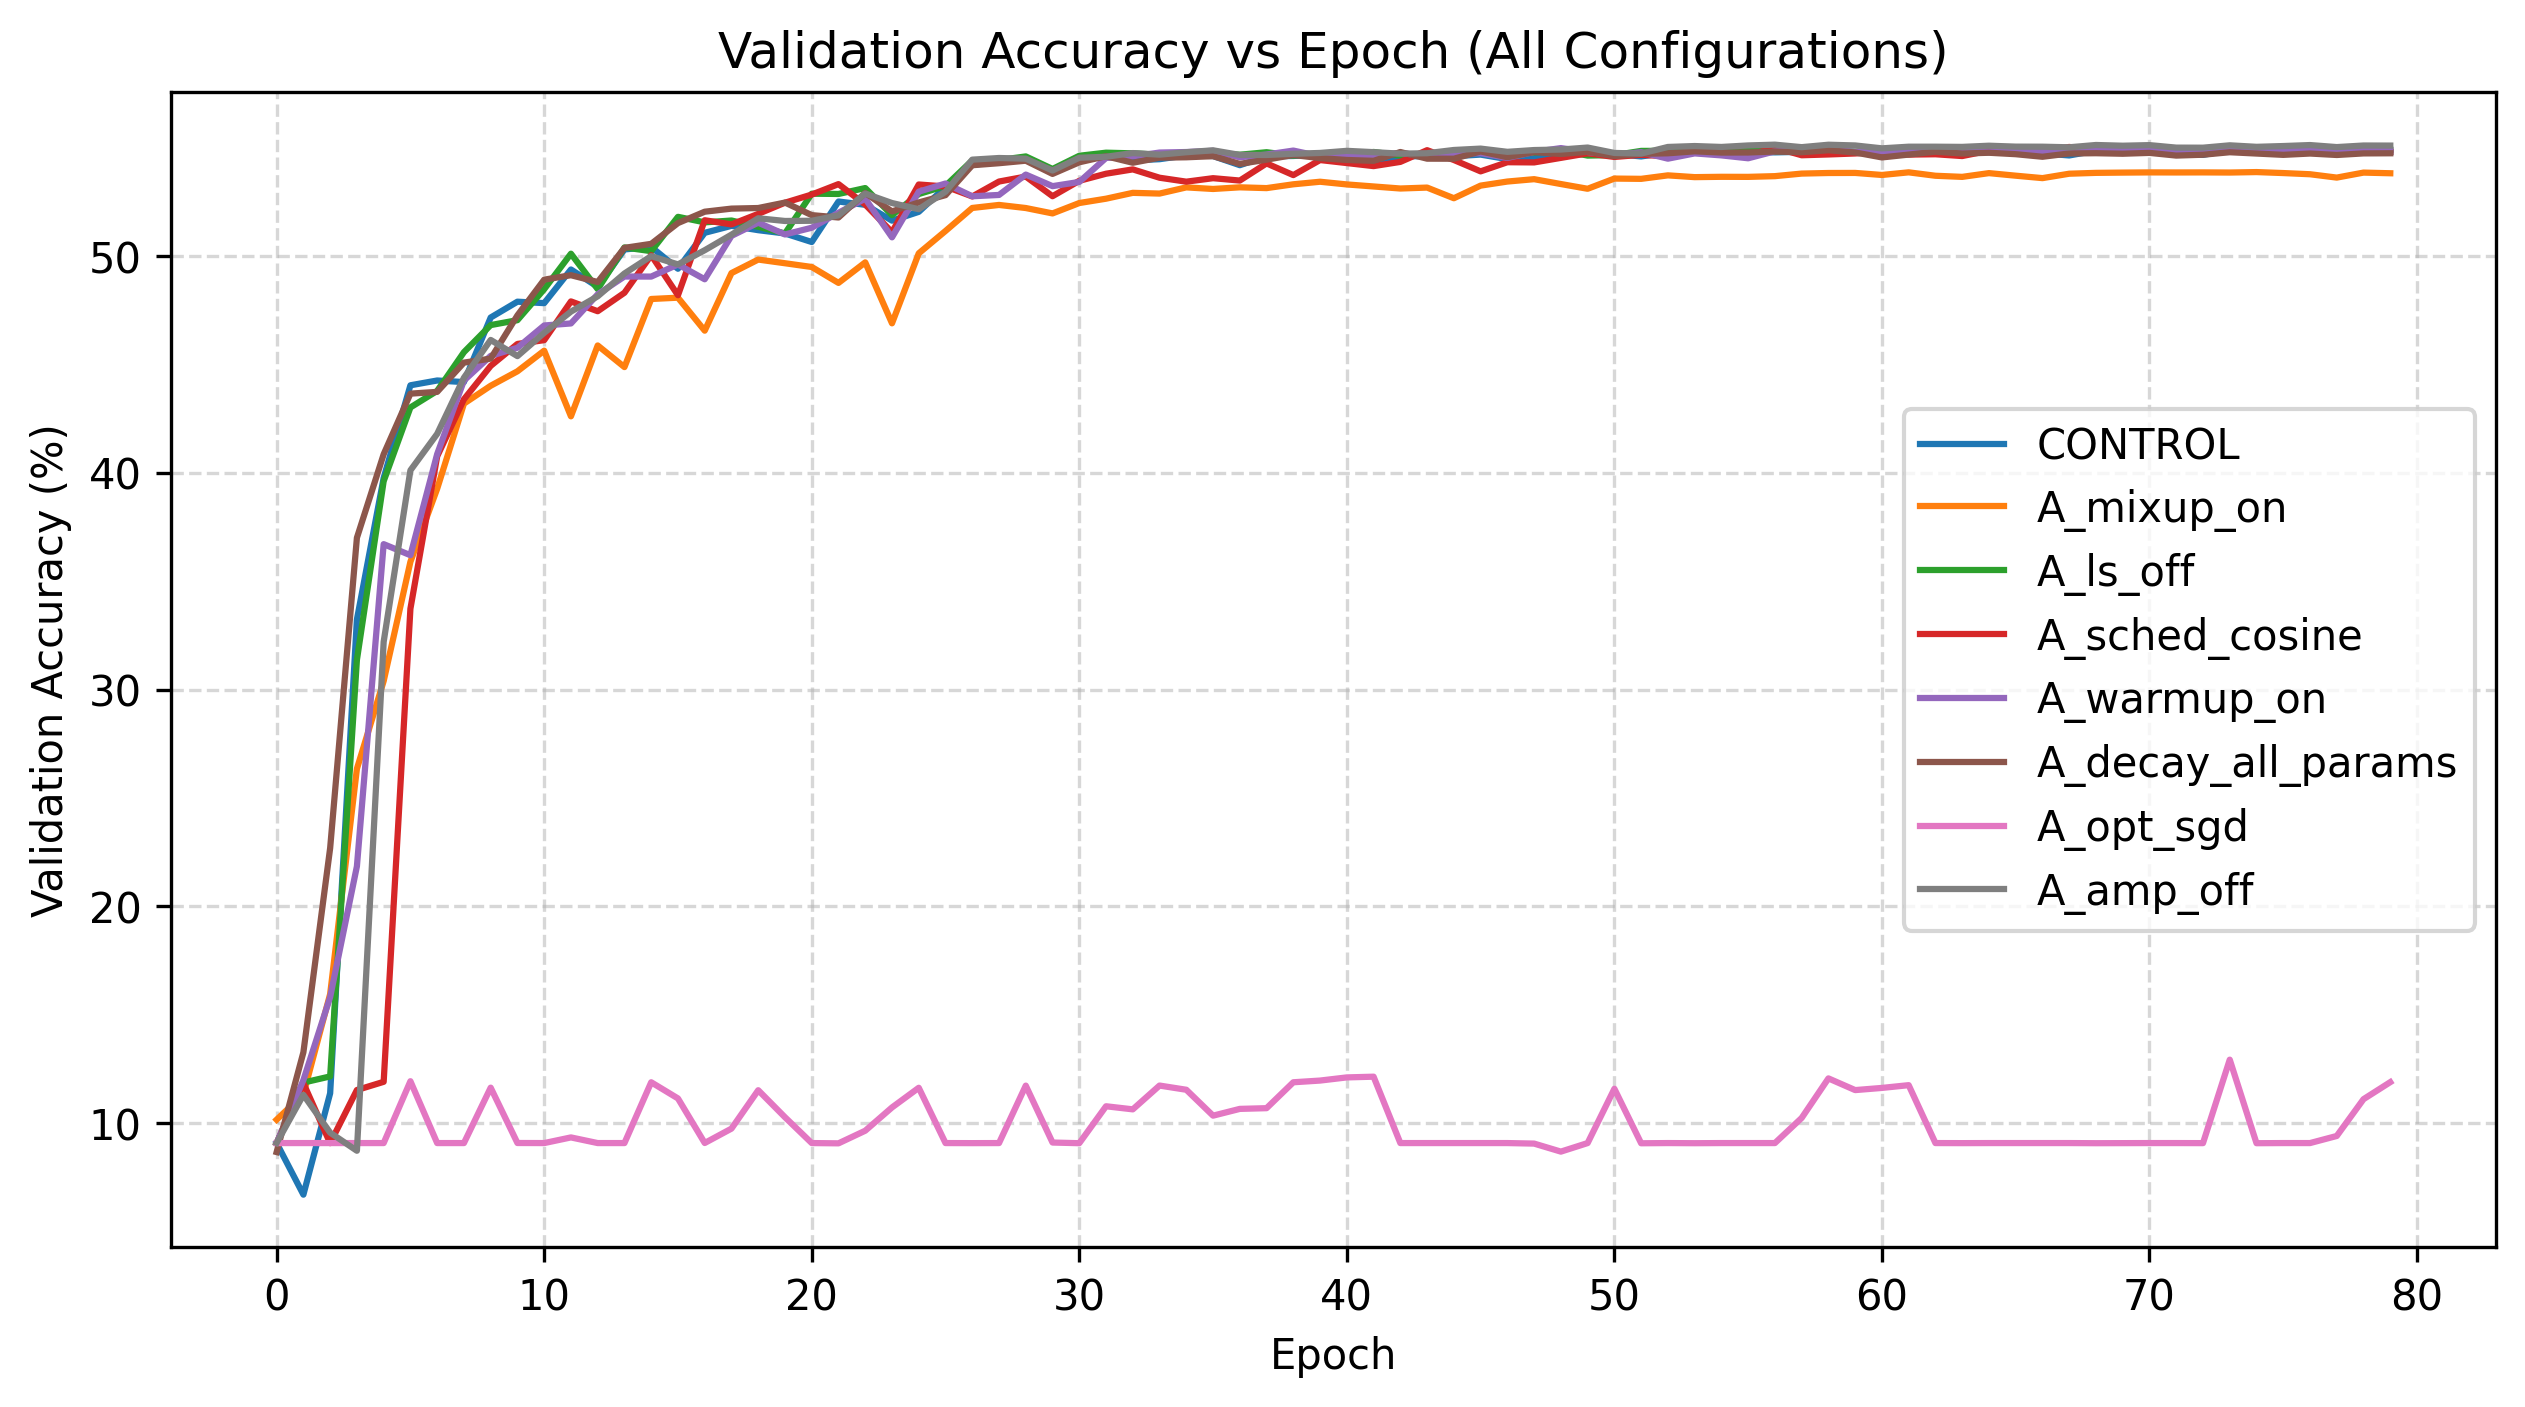

In [10]:
display(Image(filename=str(RNN_RESULTS_DIR / "val_accuracy_all_configs.png")))

### 7.3 Training and validation loss

`loss_curves_all_configs.png` plots training and validation loss for all
configurations. This is useful for spotting overfitting (train loss dropping
while validation loss increases) or unstable runs.

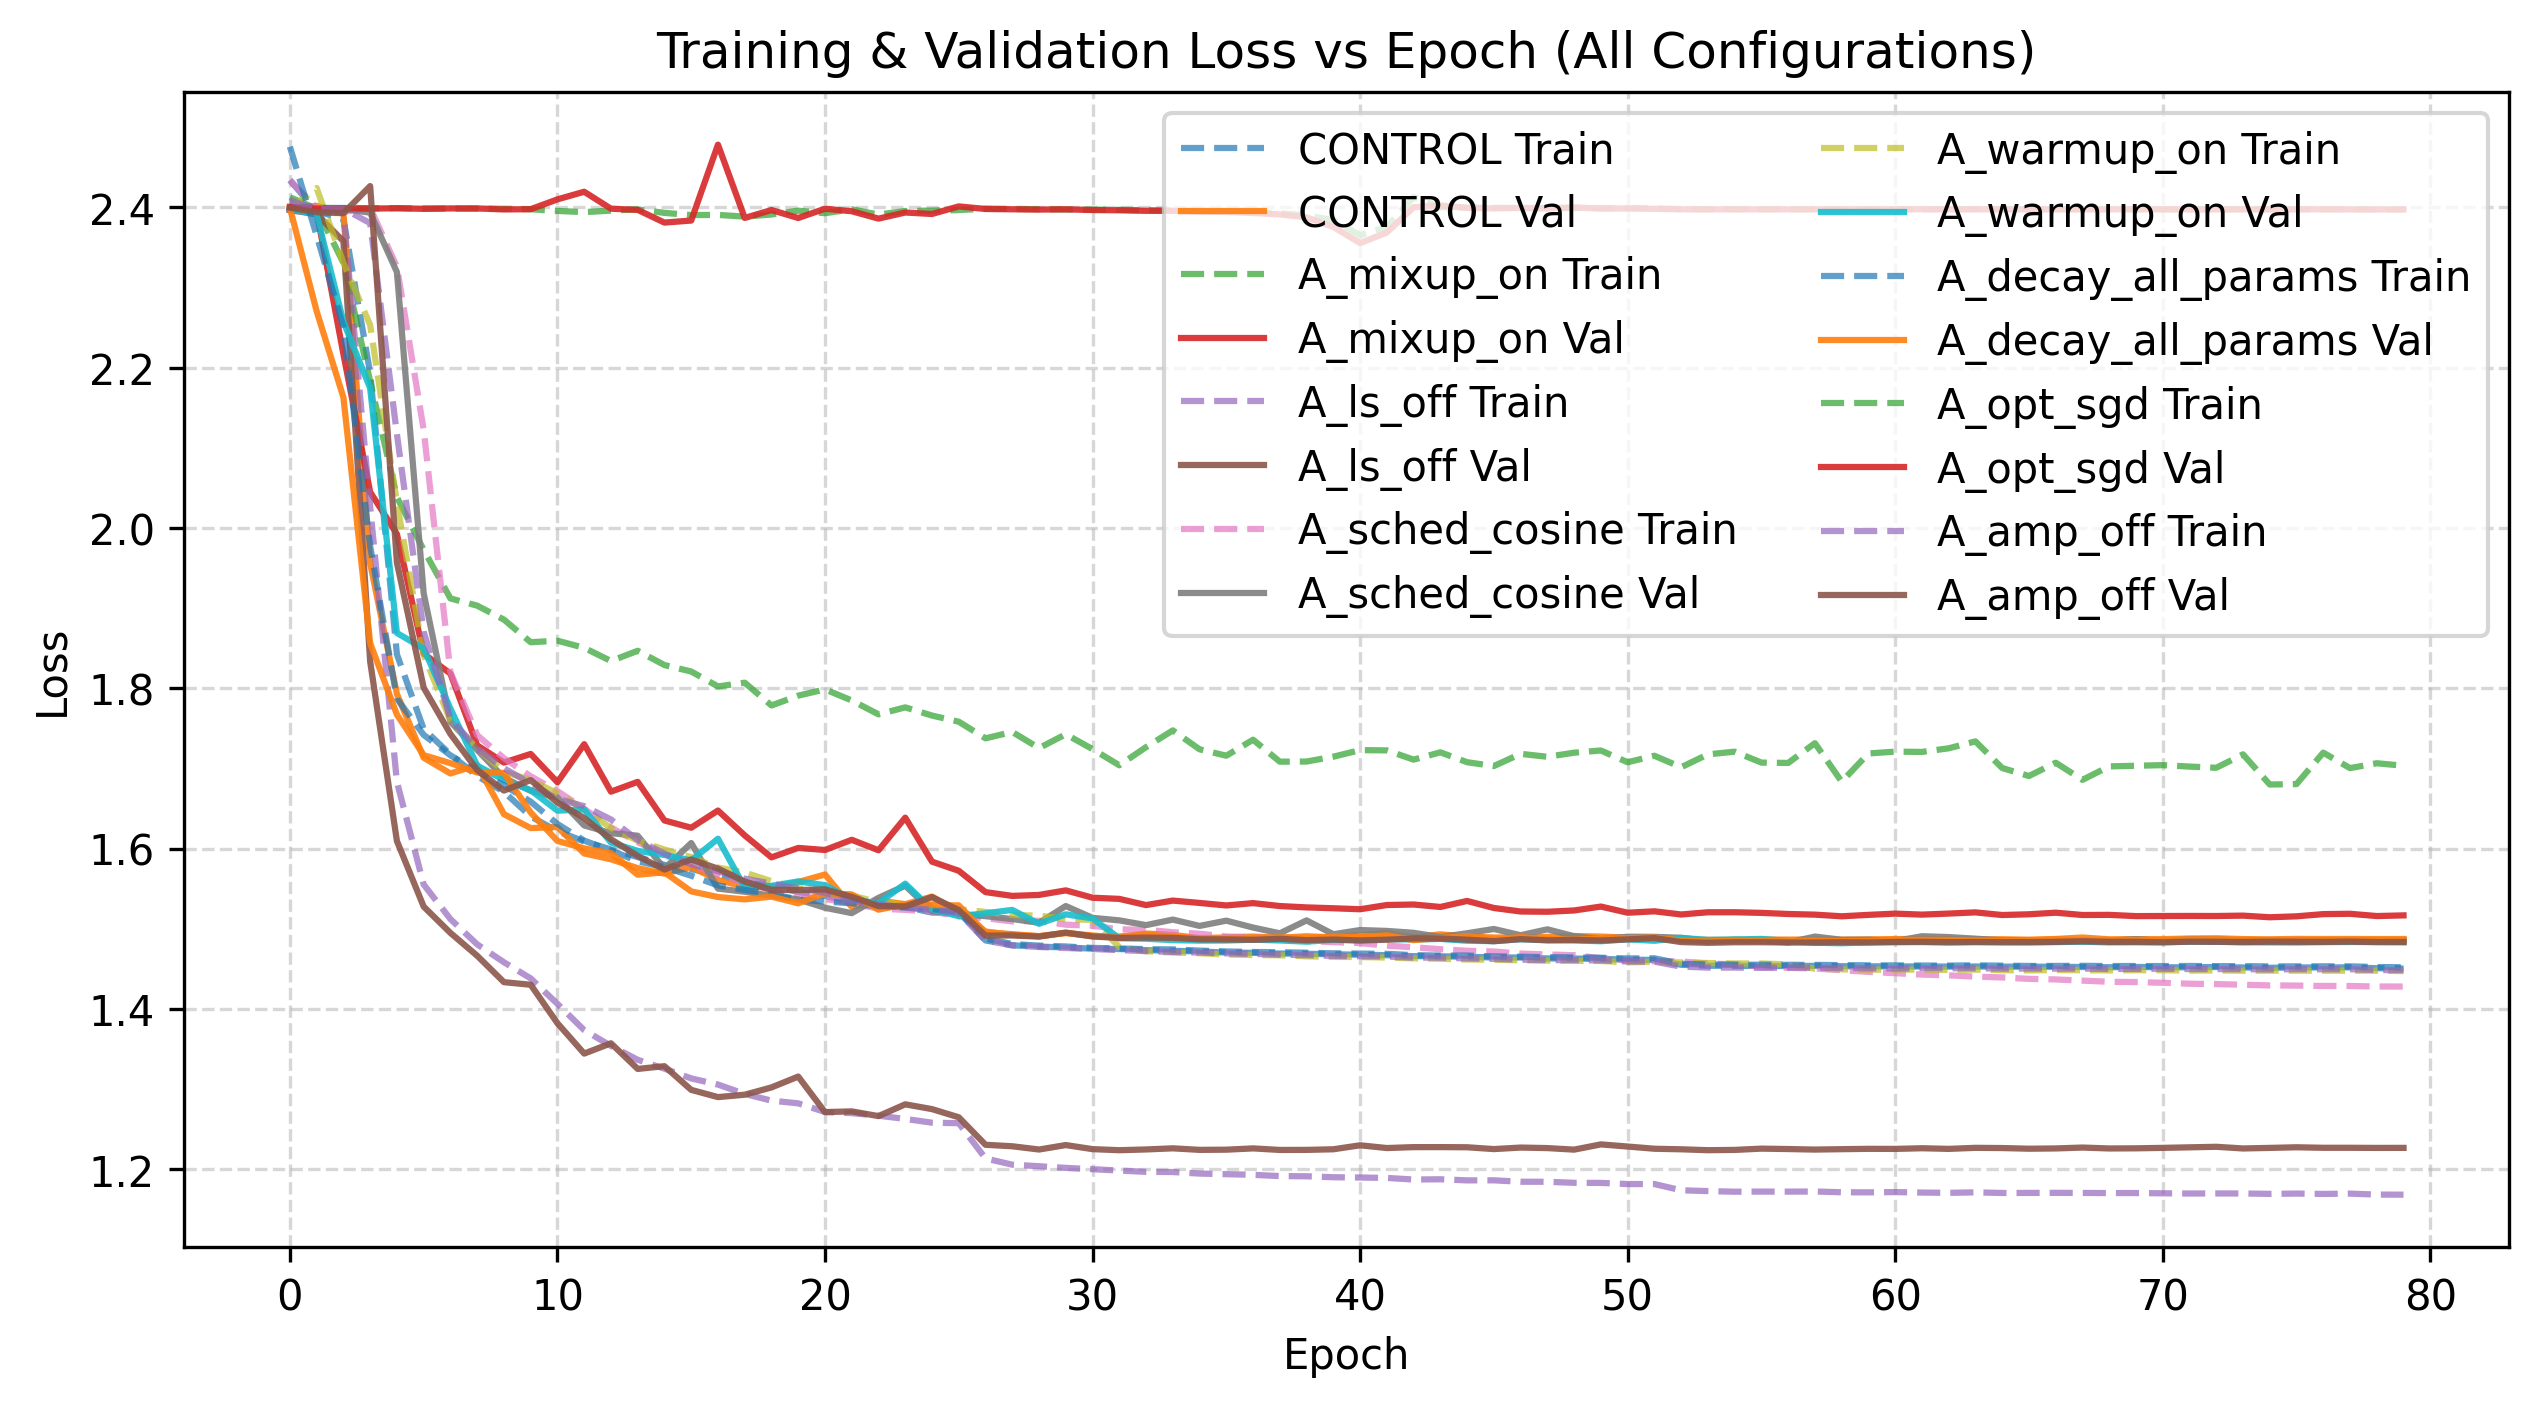

In [11]:
display(Image(filename=str(RNN_RESULTS_DIR / "loss_curves_all_configs.png")))

### 7.4 Accuracy vs SNR

`snr_accuracy_comparison.png` summarizes test accuracy as a function of SNR
for each configuration.



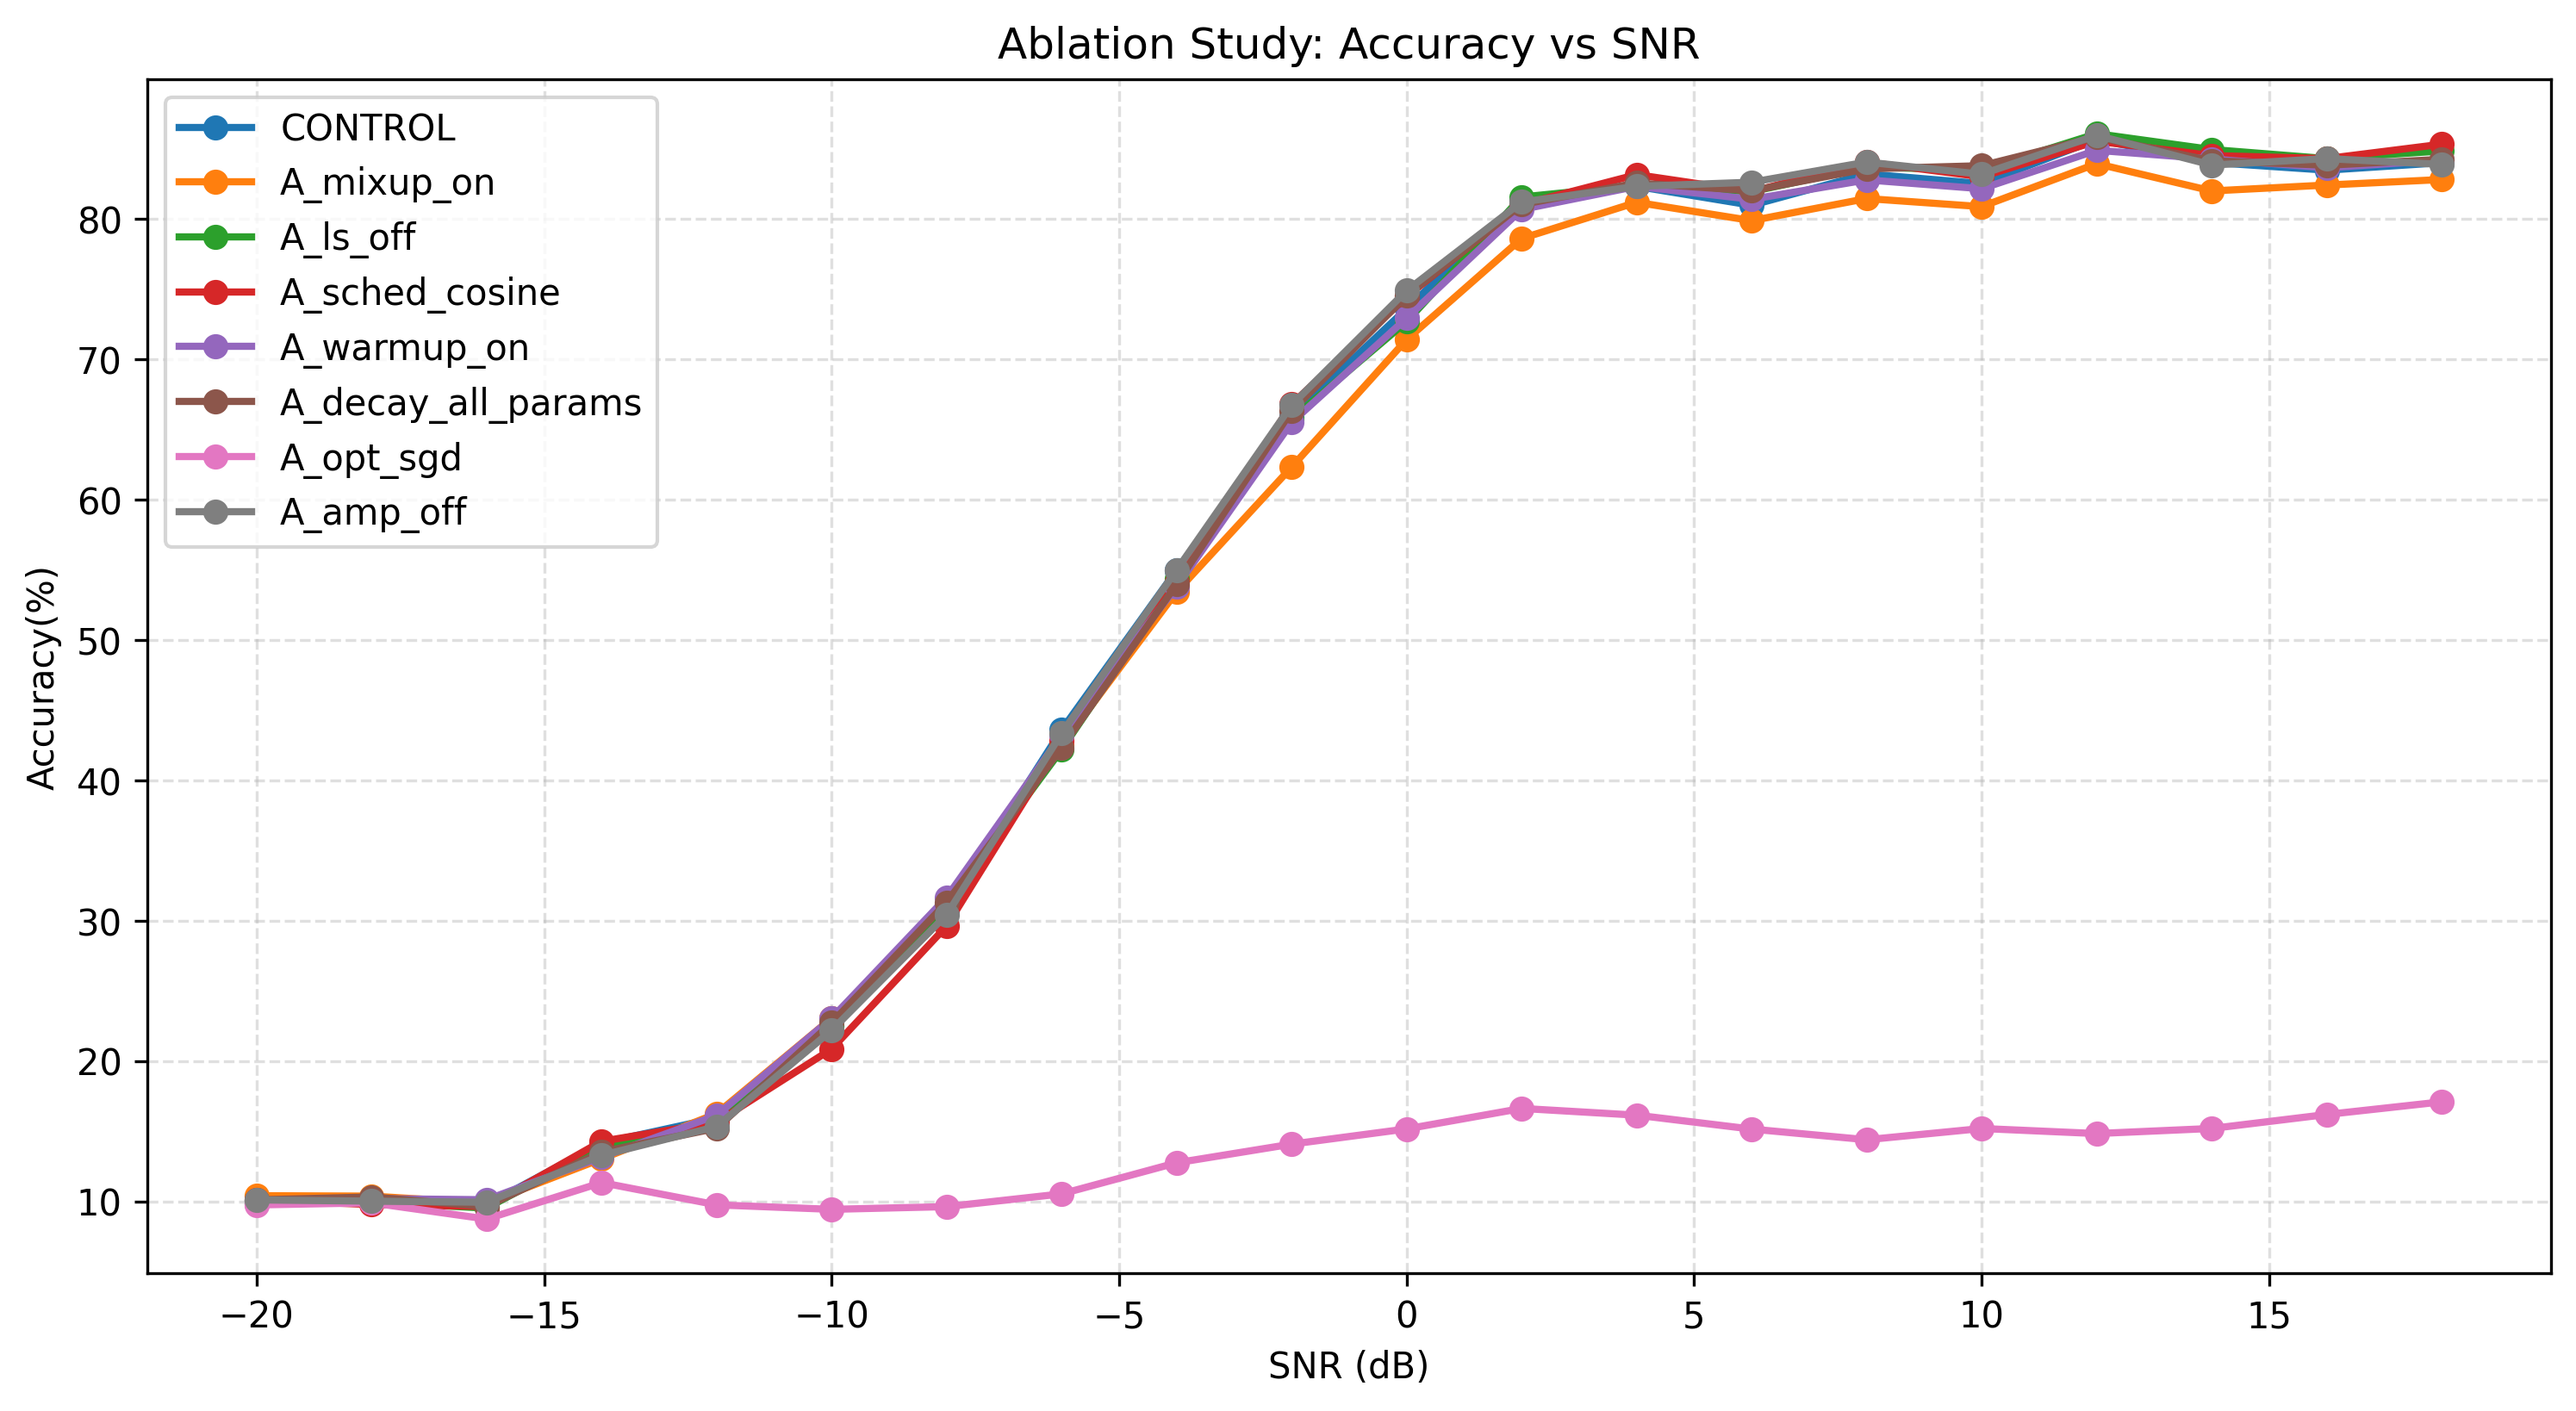

In [12]:
display(Image(filename=str(RNN_RESULTS_DIR / "snr_accuracy_comparison.png")))

---

## 8 Final selected RNN model

For the rest of the project we treat the **`A_amp_off` configuration on the
`GRU_big_h256_L2_do0.3` backbone** as the **RNN baseline**.

From `ablation_results.csv` and the “BEST_*” plots we record:

- its best validation accuracy (≈55.1%),
- its test accuracy (≈55.4% on RadioML 2016.10A),
- its training time per run (≈665 seconds, ~11 minutes on a Colab GPU),
- and its accuracy vs SNR curve.

These values will be compared directly to the 1D-CNN and hybrid CNN–RNN
models in later notebooks.


In [15]:
from rnn import AMCRNN, RNN_ARCH_CONFIGS, DEFAULT_ARCH_KEY, build_model_for_name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(mod_classes)

cfg_name = "GRU_big_h256_L2_do0.3"
model = build_model_for_name(cfg_name, num_classes=num_classes, device=device)

state = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()


AMCRNN(
  (rnn): GRU(2, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=11, bias=True)
)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_test_t = torch.from_numpy(X_test).float().to(device)  # shape (N, 2, 128)
y_test_t = torch.from_numpy(y_test).long().to(device)

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    preds = logits.argmax(dim=1).cpu().numpy()

test_acc = accuracy_score(y_test, preds)
print(f"Test accuracy (checkpoint): {test_acc*100:.2f}%")

print(classification_report(y_test, preds, target_names=mod_classes))

cm = confusion_matrix(y_test, preds)


Test accuracy (checkpoint): 55.42%
              precision    recall  f1-score   support

        8PSK       0.63      0.47      0.54      3000
      AM-DSB       0.53      0.68      0.60      3000
      AM-SSB       0.27      0.91      0.41      3000
        BPSK       0.85      0.56      0.68      3000
       CPFSK       0.79      0.59      0.67      3000
        GFSK       0.79      0.64      0.71      3000
        PAM4       0.81      0.62      0.70      3000
       QAM16       0.54      0.26      0.35      3000
       QAM64       0.60      0.63      0.62      3000
        QPSK       0.72      0.48      0.58      3000
        WBFM       0.68      0.25      0.37      3000

    accuracy                           0.55     33000
   macro avg       0.66      0.55      0.57     33000
weighted avg       0.66      0.55      0.57     33000



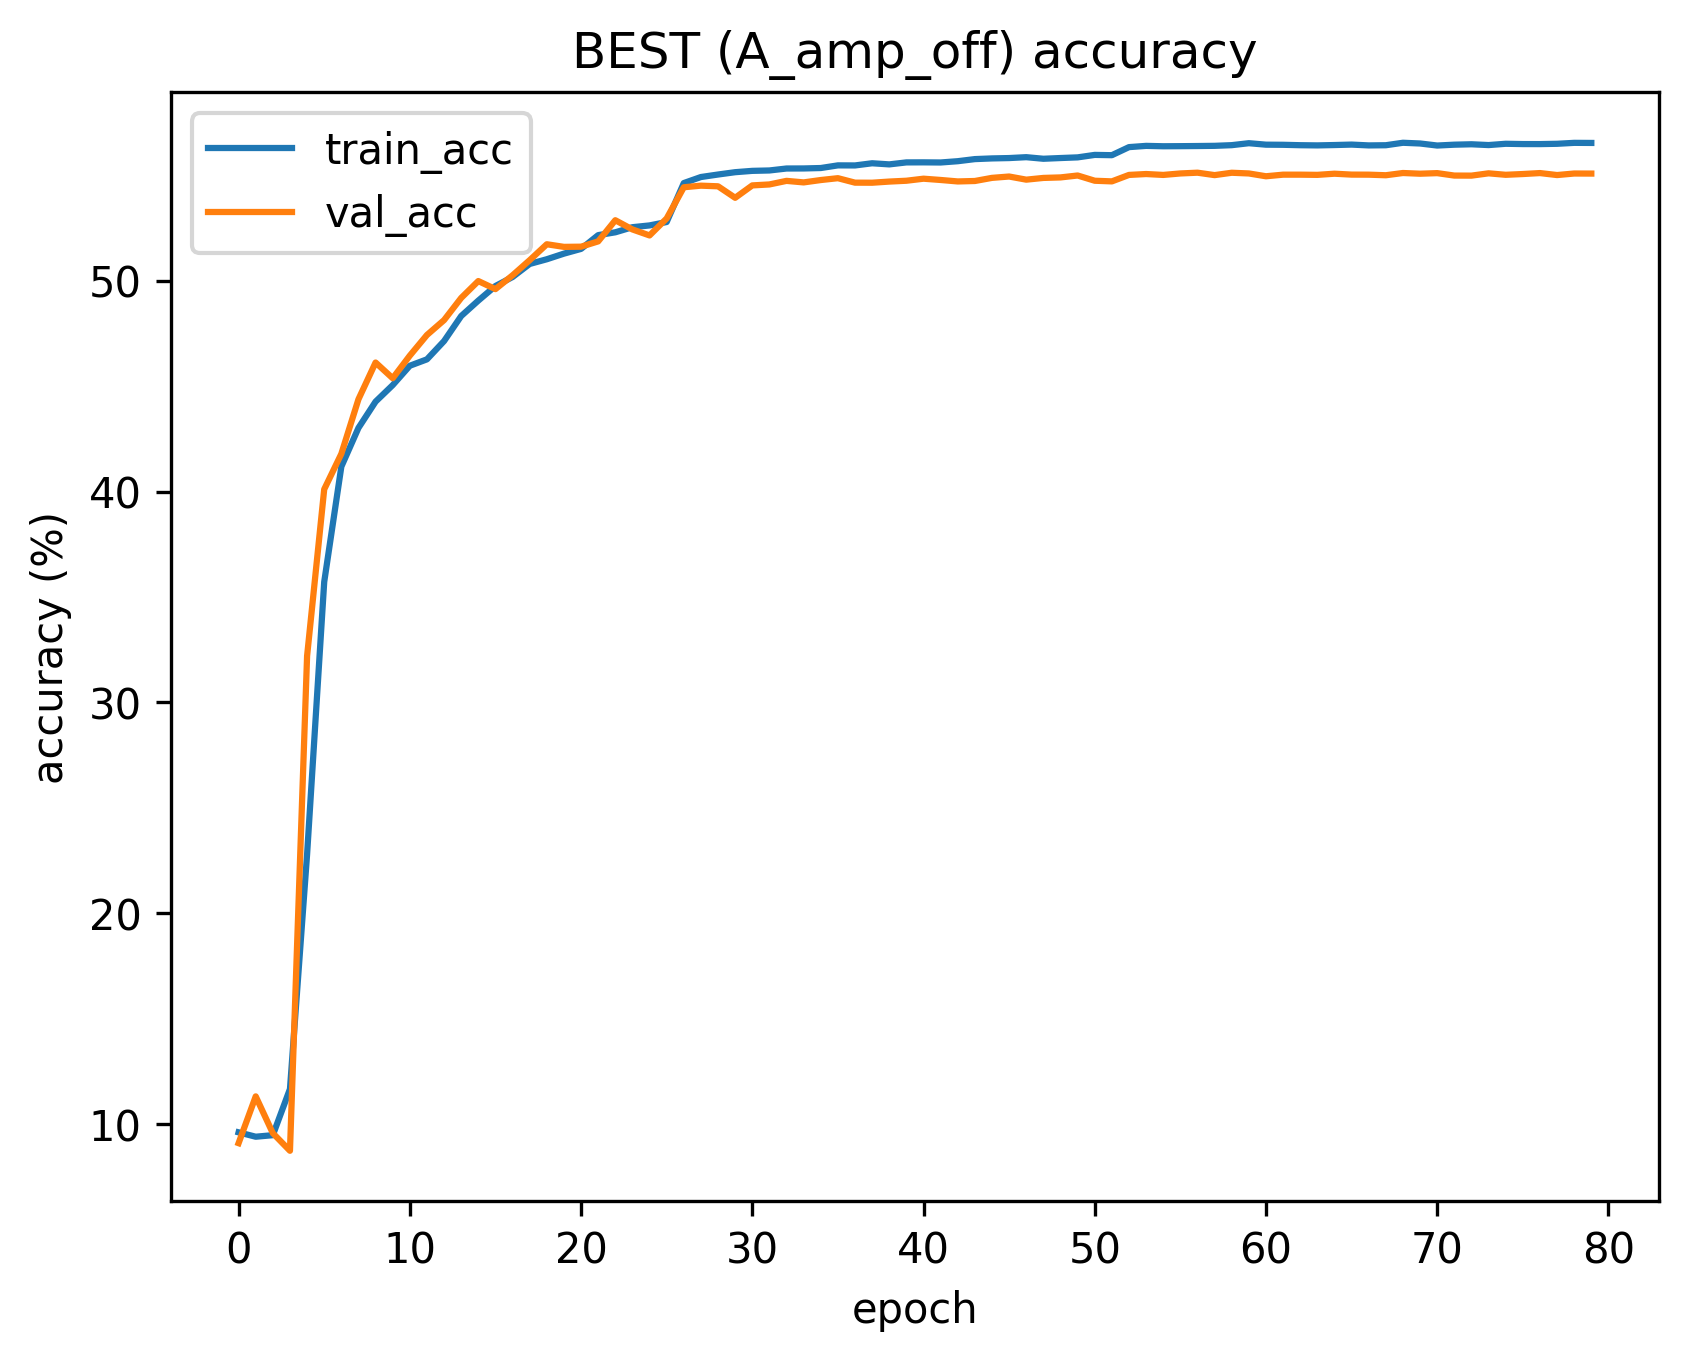

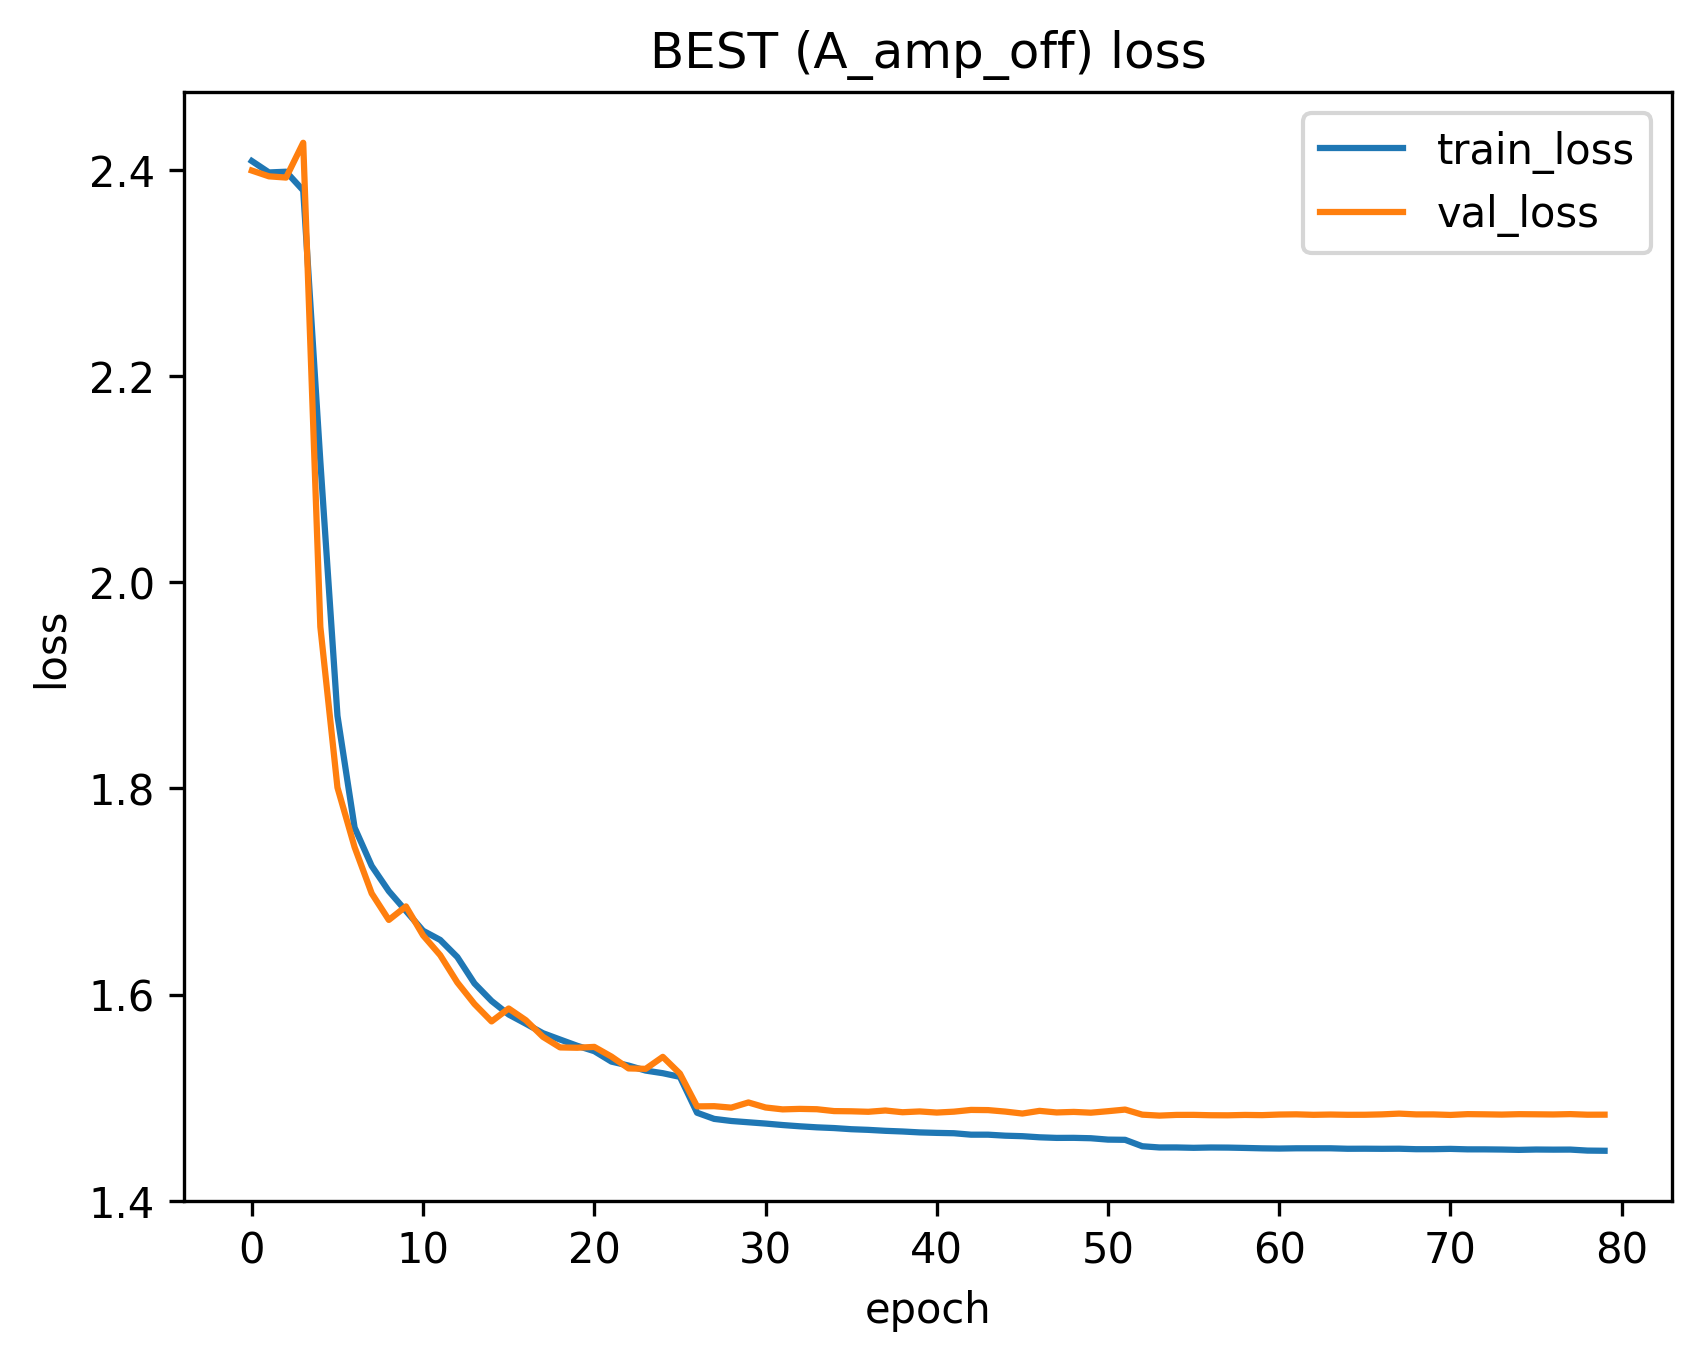

In [25]:
display(Image(filename=str(RNN_RESULTS_DIR / "BEST_acc.png")))
display(Image(filename=str(RNN_RESULTS_DIR / "BEST_loss.png")))

---

## 9 Discussion & Takeaways



### 9.1 What did the ablations show?

Stage 1:

- **Depth and width matter more than bidirectionality.**  
  Moving from the small 1-layer GRU (`GRU_base_h128_L1`) to the larger,
  2-layer GRU (`GRU_big_h256_L2_do0.3`) gives a clear jump in validation and
  test accuracy (≈55.4% test acc). In contrast, the bidirectional GRU
  (`GRU_bidir_h128_L1`) does not outperform the deeper, wider unidirectional
  model.

- **LSTM underperforms GRU.**  
  The LSTM baseline (`LSTM_base_h128_L1`) ends up significantly below the GRU
  variants.

- **RNN capacity plateaus around mid-50% accuracy.**  
  Even the best GRU configuration tops out at ≈55% test accuracy. This is
  lower than the best 1D-CNN baseline from the CNN notebook (≈60%).


Stage 2:

- **All reasonable configs land in a narrow accuracy band.**  
  Variants such as `CONTROL`, `A_ls_off`, `A_sched_cosine`,
  `A_decay_all_params`, and `A_amp_off` differ by only ≈0.1–0.2 percentage
  points in test accuracy. The best configuration (`A_amp_off`) reaches
  ≈55.4% test accuracy, but the others are very close.

- **Hyperparameter ablations mainly affect stability, not peak accuracy.**  
  Changes in optimizer (Adam vs SGD), scheduler (StepLR vs cosine), and label
  smoothing show up more clearly in the **shape of the learning curves** than
  in the final metric.

Overall, the RNNs provide a solid baseline on the RadioML data, but they fall short of the best 1D-CNN architecture when trained on the same raw I/Q inputs.


---

## 10 Next Steps
  
- **05 – CNN–RNN Hybrid & Comparison of all models**

---



### References

- T. O’Shea and J. Hoydis, “An Introduction to Deep Learning for the Physical Layer,”  
  *IEEE Transactions on Cognitive Communications and Networking*, 2017.  
  https://arxiv.org/abs/1702.00832

- T. O’Shea, J. Corgan, and T. Clancy, “Convolutional Radio Modulation Recognition Networks,” 2016.  
  https://arxiv.org/abs/1602.04105

- Ziqi Ke and Haris Vikalo, “Real-Time Radio Technology and Modulation Classification via an LSTM Auto-Encoder,”  
  The University of Texas at Austin, 2020.  
  https://arxiv.org/pdf/2011.08295

- Tong He, Zhi Zhang, Hang Zhang, Zhongyue Zhang, Junyuan Xie, and Mu Li,  
  “Bag of Tricks for Image Classification with Convolutional Neural Networks,”  
  *IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops*, 2019.  
  https://arxiv.org/abs/1812.01187

